In [50]:
import qcodes

from qcodes.instrument_drivers.Keysight import KeysightP9374A
from qcodes.instrument_drivers.Keithley import Keithley2400
from qcodes.instrument import Instrument
from qcodes.station import Station
from qcodes.parameters import DelegateParameter

from qcodes.dataset import (
    LinSweep,
    Measurement,
    dond,
    experiments,
    initialise_or_create_database_at,
    load_by_run_spec,
    load_or_create_experiment,
    plot_dataset,
)

import sys
sys.path.insert(0, r"C:\Users\eseye\Dropbox\TomMeasurement\2D_Materials\WTe2\090726_cooldown_wte2_res1\BlueFTC\src\blueftc")
from BlueforsController import BlueFTController

import matplotlib.pyplot as plt
from matplotlib import cm, colors

import numpy as np
import pandas as df
import time

In [205]:
# Plotting settings.
%config InlineBackend.figure_format = 'retina'
plt.rcParams['image.cmap'] = 'summer'

The instruments in my station are:

- A Keithley 2400 SMU.
- A BlueFors DF.
- A KeysightP9374A VNA.

I need to instantiate and set up these objects in a Station. I will do this here and then create a .yaml file that does the setup for me.

### Setup BlueFors temperature control. I need a QCodes instrument wrapper for the getter/setters for this class.

In [236]:
API_KEY = '7768e503-165b-407c-b54d-a4dac3cc4088' 
IP_ADDRESS = '10.32.83.100'
PORT_NUMBER = 49098
MXC_ID = 6
MXC_HEATER_ID = 4
PID_CALIB_FILE = r"C:\Users\eseye\Dropbox\TomMeasurement\2D_Materials\WTe2\090726_cooldown_wte2_res1\BlueFTC\examples\pid_calib.csv"

In [ ]:
class BlueForsFridge(Instrument):
    def __init__(self, name, **kwargs):
        super().__init__(name, **kwargs)
        self._controller = BlueFTController(ip=IP_ADDRESS, port=PORT_NUMBER, key=API_KEY, 
                                            mixing_chamber_channel_id=MXC_ID,
                                            mixing_chamber_heater_id=MXC_HEATER_ID,
                                            pid_calib_path=PID_CALIB_FILE)
        self.add_parameter("mxc_temperature", unit="K",
            get_cmd=self._controller.get_mxc_temperature)
        self.add_parameter("mxc_setpoint", unit="mK",
            get_cmd=self._controller.get_mxc_heater_setpoint,
            set_cmd= lambda setpoint: self._controller.set_mxc_heater_setpoint(setpoint, use_pid_calib=False)
            )
        self.add_parameter("mxc_mode", 
            get_cmd=self._controller.get_mxc_heater_mode,
            set_cmd=self._controller.set_mxc_heater_mode)

tom = BlueForsFridge(name='Tom')

### Setup Keithley 2400 SMU with correct source/sense functions and current compliance.

In [3]:
VISA_ADDRESS = "GPIB1::24::INSTR"
smu = Keithley2400("smu", VISA_ADDRESS)

CURRENT_COMPLIANCE = 1e-6
NPLC = 1
VOLT_RANGE = 20
STEP = 0.001
STEP_DWELL = 0.01

smu.parameters.pop("compliancei", None)
del smu.compliancei
smu.add_parameter("compliancei",
    get_cmd="SENS:CURR:PROT?",
    get_parser=float,
    set_cmd="SENS:CURR:PROT {:e}",
    label="Current Compliance",
    unit="A"
)

# Setup source/sense functions.
smu.mode.set('VOLT')
smu.sense.set('CURR')
smu.rangev.set(VOLT_RANGE)
smu.compliancei.set(CURRENT_COMPLIANCE)
smu.volt.step = STEP
smu.volt.inter_delay = STEP_DWELL
smu.nplci(NPLC)
smu.output(1)
smu.volt(0) # Ground now that step size is set.

class GateLeak(Exception):
    pass

class CheckedVolt(DelegateParameter):
    def __init__(self, name, source, current_param, limit, **kwargs):
        super().__init__(name, source, **kwargs)
        self._current = current_param
        self._limit = limit

    def set_raw(self, value):
        self.source(value)
        i = self._current()
        if abs(i) > self._limit:
            raise GateLeak(f"{i*1e9:.1f} nA at {value:.4f} V")

gate = CheckedVolt("gate", smu.volt, smu.curr, limit=CURRENT_COMPLIANCE, unit="V")

gate.step = STEP
gate.inter_delay = STEP_DWELL

Connected to: KEITHLEY INSTRUMENTS INC. 2400 (serial:0734512, firmware:C17   Jul 16 1999 15:20:40/A02  /G/F) in 0.31s


### Set up Keysight VNA and make sure that we are driving on HEMT input, not output.

In [ ]:
KEYSIGHT_VISA_ADDRESS = "TCPIP0::boettcher-lab-0::hislip_PXI10_CHASSIS1_SLOT1_INDEX0::INSTR"
vna = KeysightP9374A('vna',KEYSIGHT_VISA_ADDRESS)

vna.output.set(0)

try:
    for tr in vna.traces:
        tr.disable()
except:
    pass

tr = vna.enable_trace(1)
tr.trace('S21')

vna.auto_sweep.set(False)
vna.power.set(-10)
vna.averages.set(5)
vna.if_bandwidth.set(1e3)

Connected to: Keysight Technologies P9374A (serial:MY57213750, firmware:A.19.30.08) in 0.06s


### Now setting up Station!

TODO: Set up .yaml file with system addresses and compliance parameters.

In [5]:
station = Station()
station.add_component(tom)
station.add_component(smu)
station.add_component(vna)

[Tom(BlueForsFridge)] Error getting or interpreting *IDN?: ''
Traceback (most recent call last):
  File "c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\qcodes\instrument\instrument.py", line 95, in get_idn
    idstr = self.ask("*IDN?")
            ^^^^^^^^^^^^^^^^^
  File "c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\qcodes\instrument\instrument.py", line 440, in ask
    raise e
  File "c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\qcodes\instrument\instrument.py", line 434, in ask
    answer = self.ask_raw(cmd)
             ^^^^^^^^^^^^^^^^^
  File "c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\qcodes\instrument\instrument.py", line 454, in ask_raw
    raise NotImplementedError(
NotImplementedError: ('Instrument BlueForsFridge has not defined an ask method', "asking '*IDN?' to <BlueForsFridge: Tom>")
2026-09-09 14:21:43,127 :-- INFO --: Requesting value: temperature  from channel 6
c:\Users\eseye\anaconda3\envs\BoettcherB

'vna'

### Creating a dataset and running an experiment.

In [9]:
initialise_or_create_database_at(r"C:\Users\eseye\Dropbox\TomMeasurement\2D_Materials\2d_sensing.db")
qcodes.config.core.db_location

'C:\\Users\\eseye\\Dropbox\\TomMeasurement\\2D_Materials\\2d_sensing.db'

In [35]:
import numpy as np
from qcodes.parameters import Parameter, ParameterWithSetpoints
from qcodes.validators import Arrays

class Band:
    def __init__(self, name, center, span, npts, pna, trace):
        self.pna = pna
        self.trace = trace
        self.center, self.span, self.npts = center, span, npts

        self.axis = Parameter(
            f"{name}_freq", unit="Hz", label=f"{name} frequency",
            get_cmd=lambda: np.linspace(self.start, self.stop, npts),
            vals=Arrays(shape=(npts,)),
        )
        self.real = ParameterWithSetpoints(
            f"{name}_real", setpoints=(self.axis,),
            get_cmd=lambda: trace.real.get(),
            vals=Arrays(shape=(npts,)),
        )
        self.imag = ParameterWithSetpoints(
            f"{name}_imag", setpoints=(self.axis,),
            get_cmd=lambda: trace.imaginary.get(),
            vals=Arrays(shape=(npts,)),
        )

    @property
    def start(self):
        return self.center - self.span/2

    @property
    def stop(self):
        return self.center + self.span/2

    def acquire(self):
        self.pna.start(self.start)
        self.pna.stop(self.stop)
        self.pna.points(self.npts)
        self.trace.run_sweep()

### Gated RF sweep.

In [8]:
def make_setpoints(
    v_start,
    v_stop,
    v_step
):
    num_points = int(np.abs(np.round((v_stop-v_start)/v_step)) + 1)
    setpoints = np.linspace(v_start,v_stop,num_points)
    return setpoints

In [9]:
bands = [
    Band("R1", 1e9,2e9, 401, vna, tr),
    Band("R2", 2e9,3e9, 401, vna, tr),
    Band("R3", 3e9,4e9, 401, vna, tr),
]

gate_setpoints = make_setpoints(0,1,2e-1)
print('gate_setpoints',gate_setpoints)
gate_sweep = qcodes.dataset.ArraySweep(gate,gate_setpoints)

gate_setpoints [0.  0.2 0.4 0.6 0.8 1. ]


# Running dummy gate sweep.

In [ ]:
dond(
    gate_sweep,
    smu.curr,
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="dummy_resonances_vs_gate",
    write_period=1,
    do_plot=True
)

# Running dummy temperature sweep with hardware.

In [10]:
bands = [
    Band("R1", 1e9,2e9, 401, vna, tr),
    Band("R2", 2e9,3e9, 401, vna, tr),
    Band("R3", 3e9,4e9, 401, vna, tr),
]

gate_setpoints = make_setpoints(0,1,2e-1)
print('gate_setpoints',gate_setpoints)
gate_sweep = qcodes.dataset.ArraySweep(gate,gate_setpoints)

temp_setpoints = make_setpoints(10,20,5)
print('temp_setpoints',temp_setpoints)
# temp_sweep = qcodes.dataset.ArraySweep(tom.,temp_setpoints,post_actions=[temp_stabilize_delay])

gate_setpoints [0.  0.2 0.4 0.6 0.8 1. ]
temp_setpoints [10. 15. 20.]


In [ ]:
tom.mxc_mode.set(True)
tom.mxc_setpoint.set(50)
times = []
temps = []
for t in range(300):
    try:
        times.append(t)
        temps.append(tom.mxc_temperature.get())
        time.sleep(1)
    except:
        KeyboardInterrupt()
plt.plot(times,temps)

### Starting sample measurements!

Initial measurements: base temperature, grounded gate, just sweeping the resonances.

Starting experimental run with id: 1. Using 'qcodes.dataset.dond'


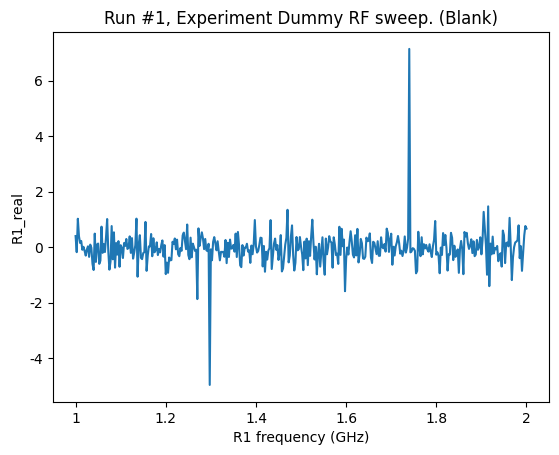

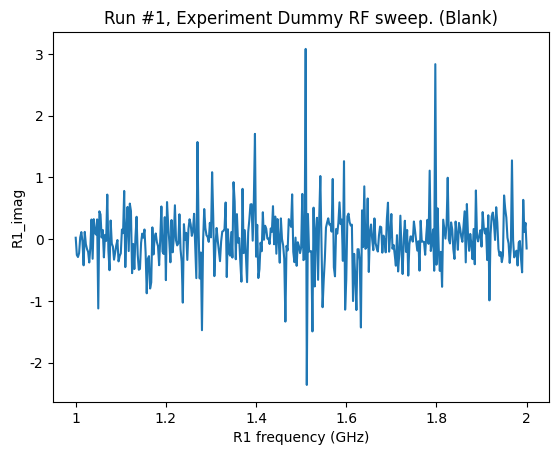

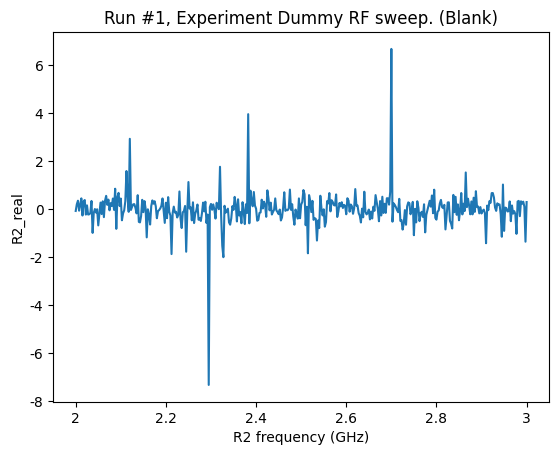

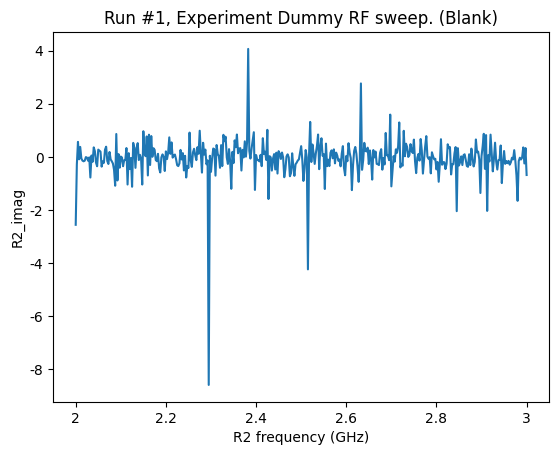

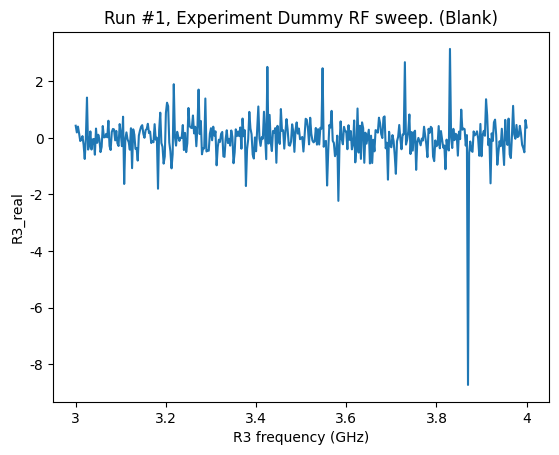

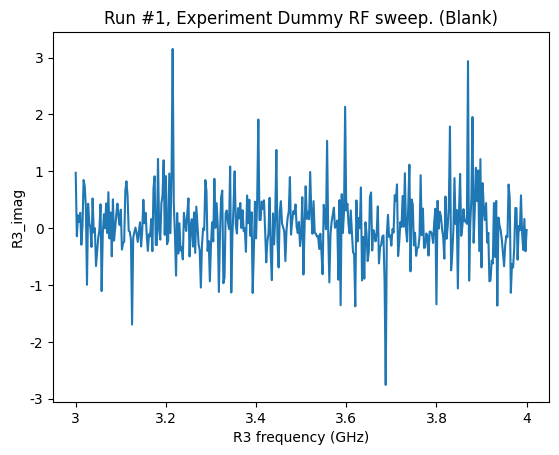

In [14]:
exp = qcodes.dataset.new_experiment(name="Dummy RF sweep.",sample_name="Blank")
result = dond(
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="Dummy RF sweep.",
    write_period=1,
    do_plot=True
)

### Initial sweep; gate grounded.
Plugging in with RF power off, then turning on.

(<Figure size 800x600 with 2 Axes>,
 (<Axes: title={'center': 'Run ID: 2 \n Sample: WTe2 R1 \n Experiment description: Initial RF sweep; gate grounded.'}, ylabel='$|S_{21}|$ (dB)'>,
  <Axes: xlabel='frequency (GHz)', ylabel='phase (rad)'>))

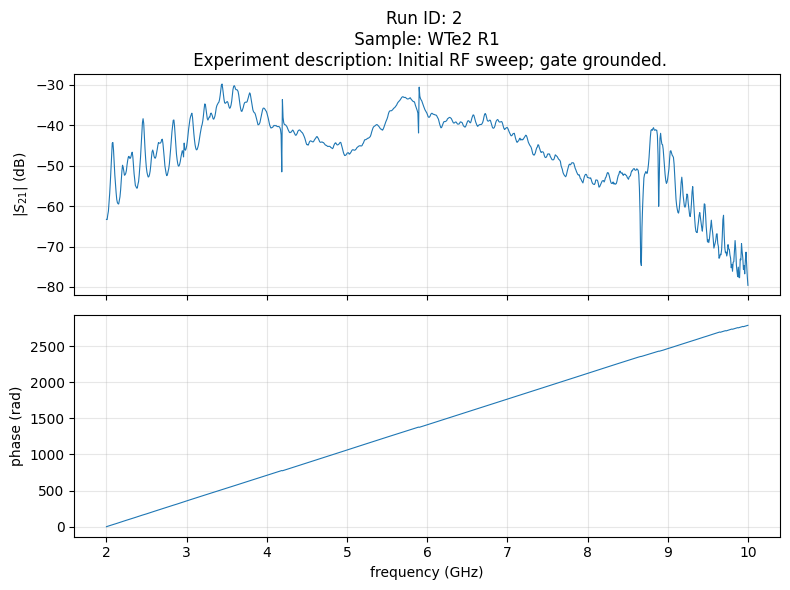

In [26]:
# Plotting this data.
ds = result[0]         

def load_band(ds, name):
    d = ds.get_parameter_data(f"{name}_real", f"{name}_imag")
    f  = d[f"{name}_real"][f"{name}_freq"].ravel()
    re = d[f"{name}_real"][f"{name}_real"].ravel()
    im = d[f"{name}_imag"][f"{name}_imag"].ravel()
    return f, re + 1j * im

def plot_band(ds, name):
    f, s21 = load_band(ds, name)
    mag_db = 20 * np.log10(np.abs(s21))
    phase  = np.unwrap(np.angle(s21))

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
    ax1.plot(f / 1e9, mag_db, lw=0.8)
    ax1.set_ylabel("$|S_{21}|$ (dB)")
    ax1.set_title(f"Run ID: {ds.captured_run_id} \n Sample: {ds.sample_name} \n Experiment description: {ds.exp_name}")
    ax1.grid(alpha=0.3)

    ax2.plot(f / 1e9, phase, lw=0.8)
    ax2.set_ylabel("phase (rad)")
    ax2.set_xlabel("frequency (GHz)")
    ax2.grid(alpha=0.3)

    fig.tight_layout()
    return fig, (ax1, ax2)

plot_band(ds, "widesweep")

In [ ]:
bands = [
    Band("lambda2", 2.965e9,100e6, 1000, vna, tr),
]
result = dond(
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="Dummy RF sweep.",
    write_period=1,
    do_plot=False
)

Starting experimental run with id: 5. Using 'qcodes.dataset.dond'


(<Figure size 800x600 with 2 Axes>,
 (<Axes: title={'center': 'Run ID: 5 \n Sample: WTe2 R1 \n Experiment description: Initial RF sweep; gate grounded.'}, ylabel='$|S_{21}|$ (dB)'>,
  <Axes: xlabel='frequency (GHz)', ylabel='phase (rad)'>))

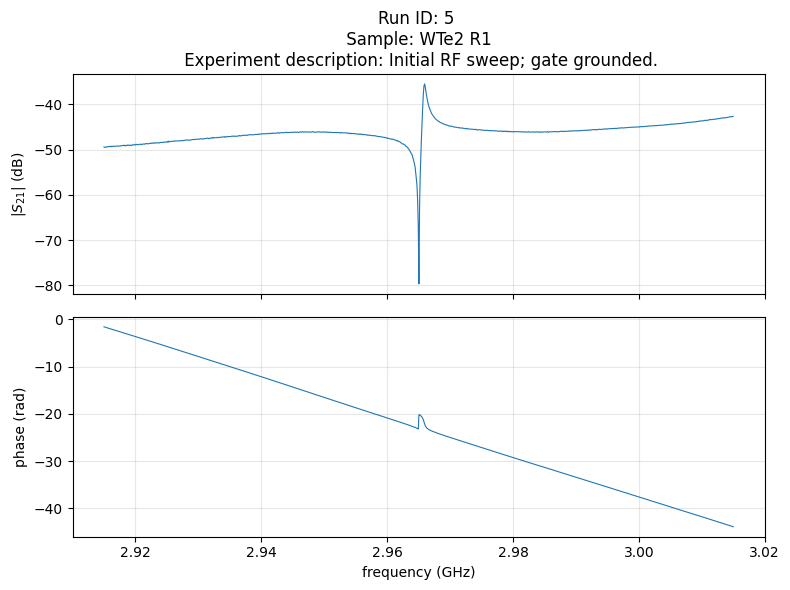

In [39]:
ds = result[0]
plot_band(ds,'lambda2')

Starting experimental run with id: 6. Using 'qcodes.dataset.dond'


(<Figure size 800x600 with 2 Axes>,
 (<Axes: title={'center': 'Run ID: 6 \n Sample: WTe2 R1 \n Experiment description: Initial RF sweep; gate grounded.'}, ylabel='$|S_{21}|$ (dB)'>,
  <Axes: xlabel='frequency (GHz)', ylabel='phase (rad)'>))

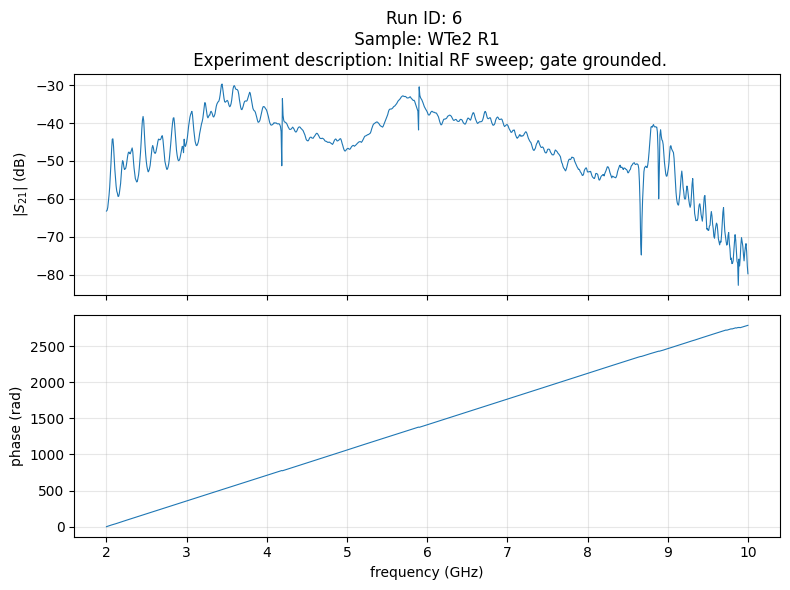

In [40]:
bands = [
    Band("widesweep", 6e9,8e9, 1000, vna, tr),
]
result = dond(
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="Dummy RF sweep.",
    write_period=1,
    do_plot=False
)
ds = result[0]
plot_band(ds,'widesweep')

In [42]:
bands = [
    Band("lambda2", 2.965e9,100e6, 1000, vna, tr),
    Band("lambda4", 4.186e9,100e6, 1000, vna, tr),
    Band("sample", 3.288e9,100e6, 1000, vna, tr),
]
result = dond(
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="Dummy RF sweep.",
    write_period=1,
    do_plot=False
)

Starting experimental run with id: 7. Using 'qcodes.dataset.dond'


In [83]:
ds = result[0]
plot_band(ds,'lambda2')

KeyError: 'lambda2_real'

### Adding gate sweep up to 3V.

In [47]:
bands = [
    Band("lambda2", 2.965e9,100e6, 1000, vna, tr),
    Band("lambda4", 4.186e9,100e6, 1000, vna, tr),
    Band("sample", 3.288e9,100e6, 1000, vna, tr),
]

exp = qcodes.dataset.new_experiment(name="RF sweep with dummy gate.",sample_name="WTe2 R1")

gate_setpoints = make_setpoints(0,1.95,1e-1) # Sweep step size is 100mV.
print('gate_setpoints',gate_setpoints)
gate_sweep = qcodes.dataset.ArraySweep(gate,gate_setpoints)

gate_setpoints [0.     0.0975 0.195  0.2925 0.39   0.4875 0.585  0.6825 0.78   0.8775
 0.975  1.0725 1.17   1.2675 1.365  1.4625 1.56   1.6575 1.755  1.8525
 1.95  ]


In [48]:
result = dond(
    gate_sweep,
    smu.curr,
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="RF sweep with dummy gate.",
    exp=exp,
    write_period=1,
    do_plot=False
)

Starting experimental run with id: 8. Using 'qcodes.dataset.dond'


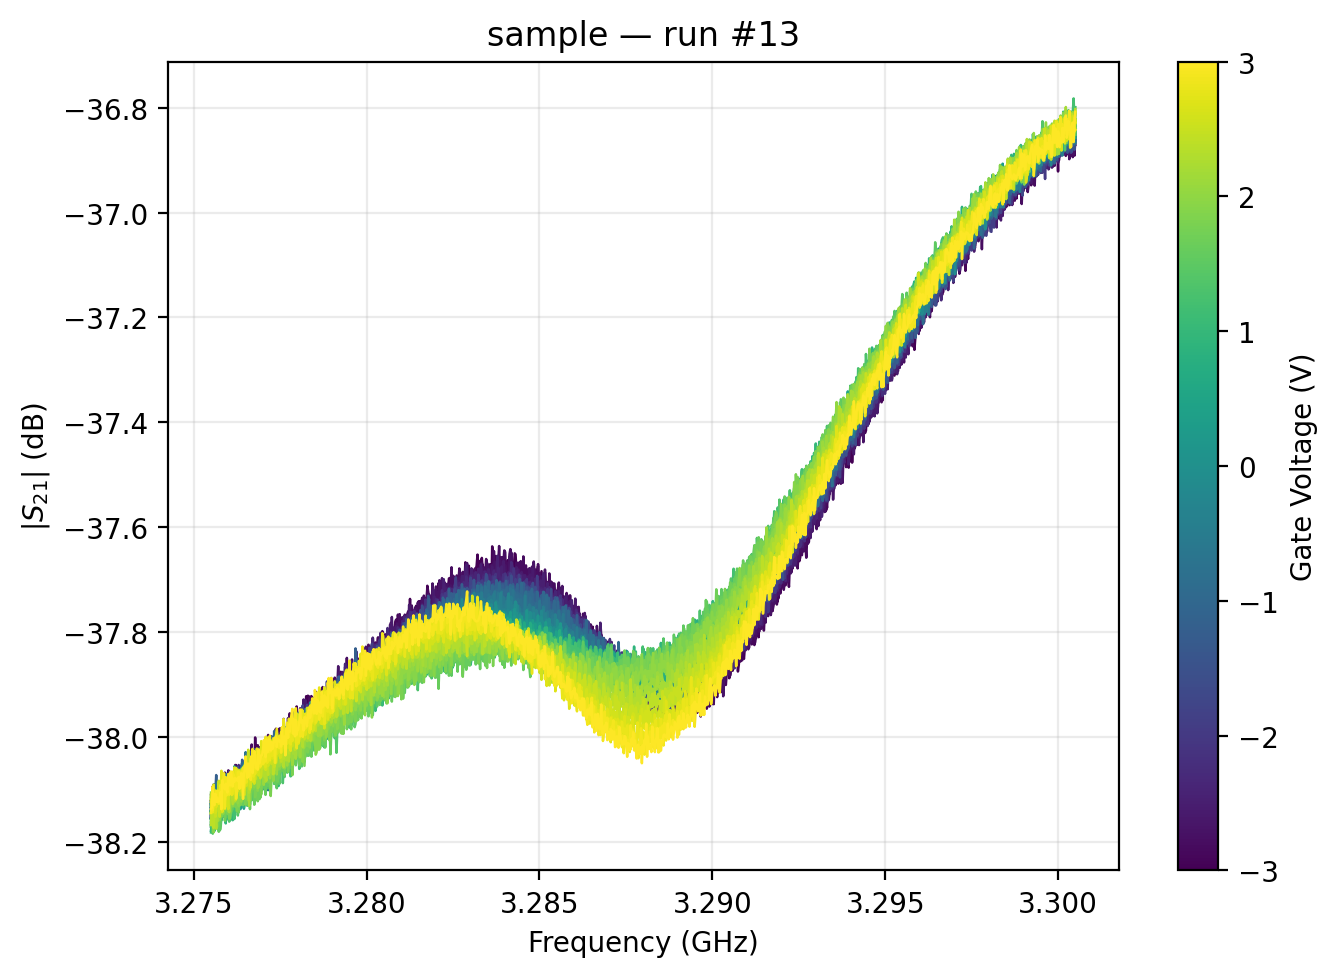

In [231]:
def load_band_2d(ds, name):
    """Return (gate [n], freq [m], s21 [n, m]) for one band."""
    d = ds.get_parameter_data(f"{name}_real", f"{name}_imag")
    re_block, im_block = d[f"{name}_real"], d[f"{name}_imag"]

    gate = re_block["gate"][:, 0]              # setpoint name; see note below
    freq = re_block[f"{name}_freq"][0, :]      # identical for every row
    s21 = re_block[f"{name}_real"] + 1j * im_block[f"{name}_imag"]
    return gate, freq, s21

def plot_2d(ds, name, cmap="viridis", offset_db=0.0, ax=None,
            vmin=None, vmax=None, title=None):
    gate, freq, s21 = load_band_2d(ds, name)
    mag_db = 20 * np.log10(np.abs(s21)) + offset_db

    # orient as (gate, freq) so rows are gate steps
    if mag_db.shape != (freq.size,gate.size):
        mag_db = mag_db.T

    if vmin is None:
        vmin = np.nanpercentile(mag_db, 2)
    if vmax is None:
        vmax = np.nanpercentile(mag_db, 98)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    else:
        fig = ax.get_figure()

    mesh = ax.pcolormesh(
        gate, freq / 1e9, mag_db,
        cmap=cmap, shading="nearest",
        norm=colors.Normalize(vmin=vmin, vmax=vmax),
        rasterized=True,
    )

    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(r"$|S_{21}|$  (dB)")
    cbar.ax.tick_params(labelsize=9)

    ax.set_ylabel("Frequency (GHz)")
    ax.set_xlabel("Gate voltage (V)")
    ax.set_title(title or f"{name} — run #{ds.run_id}", pad=10)
    ax.tick_params(direction="out", length=4, top=False, right=False)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    return fig, ax

def plot_linecuts(ds, name, cmap="viridis", offset_db=0.0, ax=None):
    gate, freq, s21 = load_band_2d(ds, name)
    mag_db = 20 * np.log10(np.abs(s21))

    norm = colors.Normalize(vmin=gate.min(), vmax=gate.max())
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    for i, v in enumerate(gate):
        ax.plot(freq / 1e9, mag_db[i] + i * offset_db,
                color=sm.to_rgba(v), lw=0.9)

    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("|$S_{21}$| (dB)" + (" + offset" if offset_db else ""))
    ax.set_title(f"{name} — run #{ds.captured_run_id}")
    ax.grid(alpha=0.25)

    cb = fig.colorbar(sm, ax=ax)
    cb.set_label("Gate Voltage (V)")
    fig.tight_layout()
    return fig, ax


ds = result[0]
for b in bands:
    plot_linecuts(ds, b.axis.name.removesuffix("_freq"))

In [53]:
bands = [
    Band("lambda2", 2.965e9,50e6, 1000, vna, tr),
    Band("lambda4", 4.186e9,50e6, 1000, vna, tr),
    Band("sample", 3.288e9,50e6, 1000, vna, tr),
]

gate_setpoints = make_setpoints(0,0.2,1e-1) # Sweep step size is 100mV.
print('gate_setpoints',gate_setpoints)
gate_sweep = qcodes.dataset.ArraySweep(gate,gate_setpoints)

gate_setpoints [0.  0.1 0.2]


Starting experimental run with id: 9. Using 'qcodes.dataset.dond'


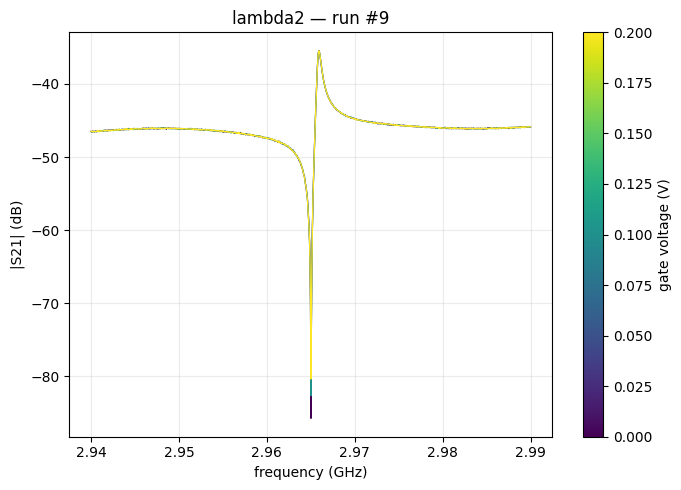

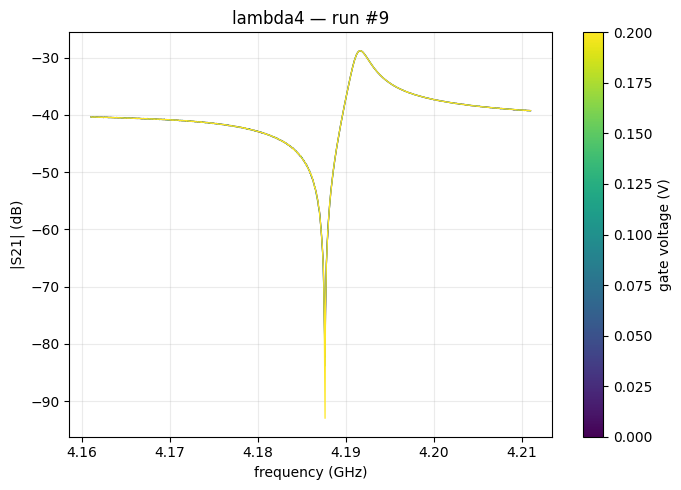

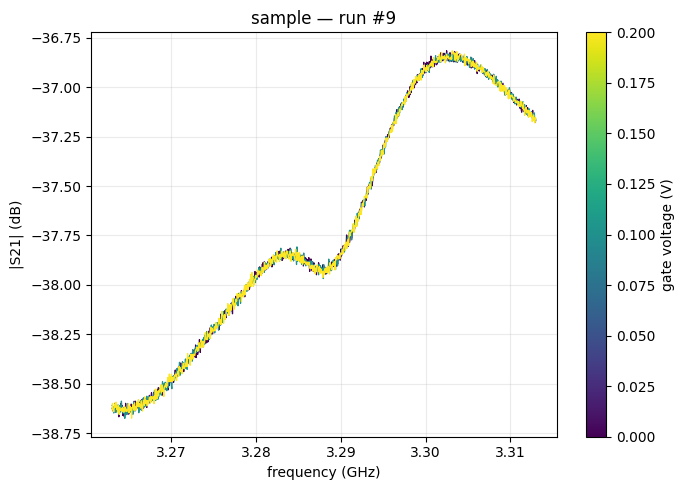

In [54]:
result = dond(
    gate_sweep,
    smu.curr,
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="RF sweep with dummy gate.",
    exp=exp,
    write_period=1,
    do_plot=False
)
ds = result[0]
for b in bands:
    plot_linecuts(ds, b.axis.name.removesuffix("_freq"))

### On the real sample this time!

In [72]:
bands = [
    Band("sample", 3.288e9,25e6, 1000, vna, tr),
]
gate_setpoints = make_setpoints(0,3,1e-1) # Sweep step size is 100mV.
print('gate_setpoints',gate_setpoints)
gate_sweep = qcodes.dataset.ArraySweep(gate,gate_setpoints)

gate_setpoints [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3. ]


In [73]:
smu.volt.set(0)
# CURRENT_COMPLIANCE = 1e-9
# smu.compliancei.set(CURRENT_COMPLIANCE)
# gate._limit = CURRENT_COMPLIANCE

In [74]:
result = dond(
    gate_sweep,
    smu.curr,
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="RF sweep with real gate.",
    write_period=1,
    do_plot=False
)

Starting experimental run with id: 10. Using 'qcodes.dataset.dond'


In [82]:
result[0].exp_id

5

Text(0.5, 1.0, 'WTe2 R1')

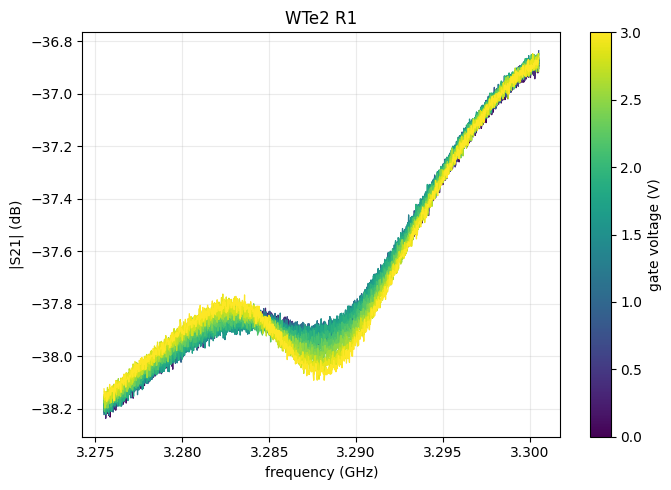

In [78]:
ds = result[0]
b = bands[0]
fig,ax = plot_linecuts(ds, b.axis.name.removesuffix("_freq"))
ax.set_title("WTe2 R1")

In [86]:
bands = [
    Band("sample", 3.288e9,25e6, 1000, vna, tr),
]
gate_setpoints = make_setpoints(3,-1.5,1e-1) # Sweep step size is 100mV.
print('gate_setpoints',gate_setpoints)
gate_sweep = qcodes.dataset.ArraySweep(gate,gate_setpoints)

gate_setpoints [ 3.   2.9  2.8  2.7  2.6  2.5  2.4  2.3  2.2  2.1  2.   1.9  1.8  1.7
  1.6  1.5  1.4  1.3  1.2  1.1  1.   0.9  0.8  0.7  0.6  0.5  0.4  0.3
  0.2  0.1  0.  -0.1 -0.2 -0.3 -0.4 -0.5 -0.6 -0.7 -0.8 -0.9 -1.  -1.1
 -1.2 -1.3 -1.4 -1.5]


In [87]:
# Sweep to -2V on the gate to check.
result = dond(
    gate_sweep,
    smu.curr,
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="RF sweep with real gate: 3V to -1.5V.",
    write_period=1,
    do_plot=False
)

Starting experimental run with id: 11. Using 'qcodes.dataset.dond'


Text(0.5, 1.0, 'WTe2 R1')

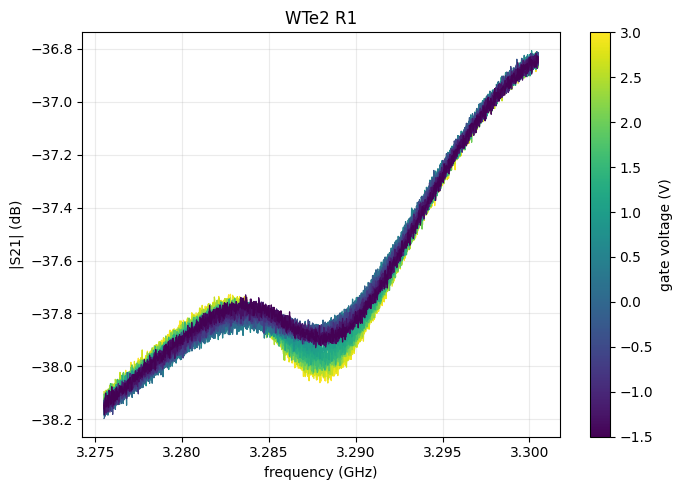

In [88]:
ds = result[0]
b = bands[0]
fig,ax = plot_linecuts(ds, b.axis.name.removesuffix("_freq"))
ax.set_title("WTe2 R1")

- This is consistent with doping on the other side! Screening is a bit better? Not consistent with a bandgap... Consistent with decreased backscattering in edge modes?

- Sweeping down to -3V to see if it's symmetric!

- If we can fit Q as a function of gate voltage that tells us the effective resistance of our channel. Can we correlate to improved screening in edge channels?

In [89]:
bands = [
    Band("sample", 3.288e9,25e6, 1000, vna, tr),
]
gate_setpoints = make_setpoints(-1.5,-3,1e-1) # Sweep step size is 100mV.
print('gate_setpoints',gate_setpoints)
gate_sweep = qcodes.dataset.ArraySweep(gate,gate_setpoints)

gate_setpoints [-1.5 -1.6 -1.7 -1.8 -1.9 -2.  -2.1 -2.2 -2.3 -2.4 -2.5 -2.6 -2.7 -2.8
 -2.9 -3. ]


In [90]:
# Sweep to -2V on the gate to check.
result = dond(
    gate_sweep,
    smu.curr,
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="RF sweep with real gate: -1.5V to -3V.",
    write_period=1,
    do_plot=False
)

Starting experimental run with id: 12. Using 'qcodes.dataset.dond'


Text(0.5, 1.0, 'WTe2 R1')

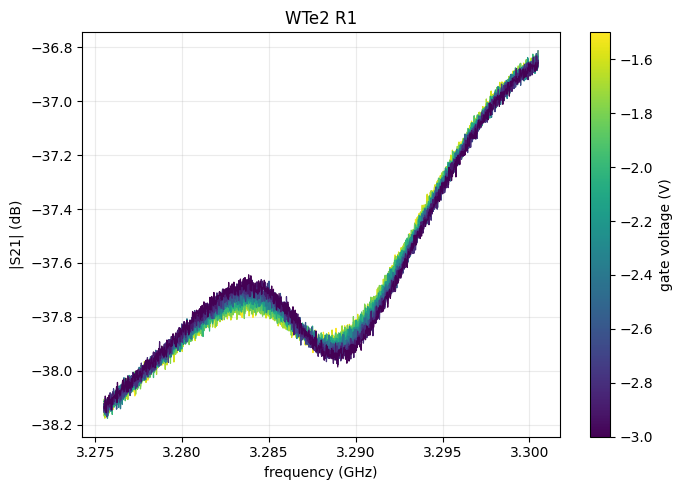

In [91]:
ds = result[0]
b = bands[0]
fig,ax = plot_linecuts(ds, b.axis.name.removesuffix("_freq"))
ax.set_title("WTe2 R1")

In [99]:
ds_list = []
for run_id in [10,11,12]:
    ds = load_by_run_spec(captured_run_id=run_id,experiment_name='RF sweep with dummy gate.')
    ds_list.append(ds)

### I'm too lazy: just running from -3V to +3V again.

In [102]:
bands = [
    Band("sample", 3.288e9,25e6, 1000, vna, tr),
]
gate_setpoints = make_setpoints(-3,3,1e-1) # Sweep step size is 100mV.
print('gate_setpoints',gate_setpoints)
gate_sweep = qcodes.dataset.ArraySweep(gate,gate_setpoints)

gate_setpoints [-3.  -2.9 -2.8 -2.7 -2.6 -2.5 -2.4 -2.3 -2.2 -2.1 -2.  -1.9 -1.8 -1.7
 -1.6 -1.5 -1.4 -1.3 -1.2 -1.1 -1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3
 -0.2 -0.1  0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1
  1.2  1.3  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5
  2.6  2.7  2.8  2.9  3. ]


In [103]:
result = dond(
    gate_sweep,
    smu.curr,
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="RF sweep with real gate: -1.5V to -3V.",
    write_period=1,
    do_plot=False
)

Starting experimental run with id: 13. Using 'qcodes.dataset.dond'


In [189]:
guid='2c3c6564-0000-0000-0000-01a088a57f09'
ds = qcodes.dataset.load_by_guid(guid)
ds.get_parameters()

[ParamSpec('gate', 'numeric', 'Voltage', 'V', inferred_from=[], depends_on=[]),
 ParamSpec('sample_freq', 'array', 'sample frequency', 'Hz', inferred_from=[], depends_on=[]),
 ParamSpec('smu_curr', 'numeric', 'Current', 'A', inferred_from=[], depends_on=['gate']),
 ParamSpec('sample_real', 'array', 'sample_real', '', inferred_from=[], depends_on=['gate', 'sample_freq']),
 ParamSpec('sample_imag', 'array', 'sample_imag', '', inferred_from=[], depends_on=['gate', 'sample_freq'])]

13
5
WTe2 R1
2c3c6564-0000-0000-0000-01a088a57f09


Text(0.5, 1.0, 'Sample WTe2 R1 \n Exp. #5 Run #13 \n GUID: 2c3c6564-0000-0000-0000-01a088a57f09')

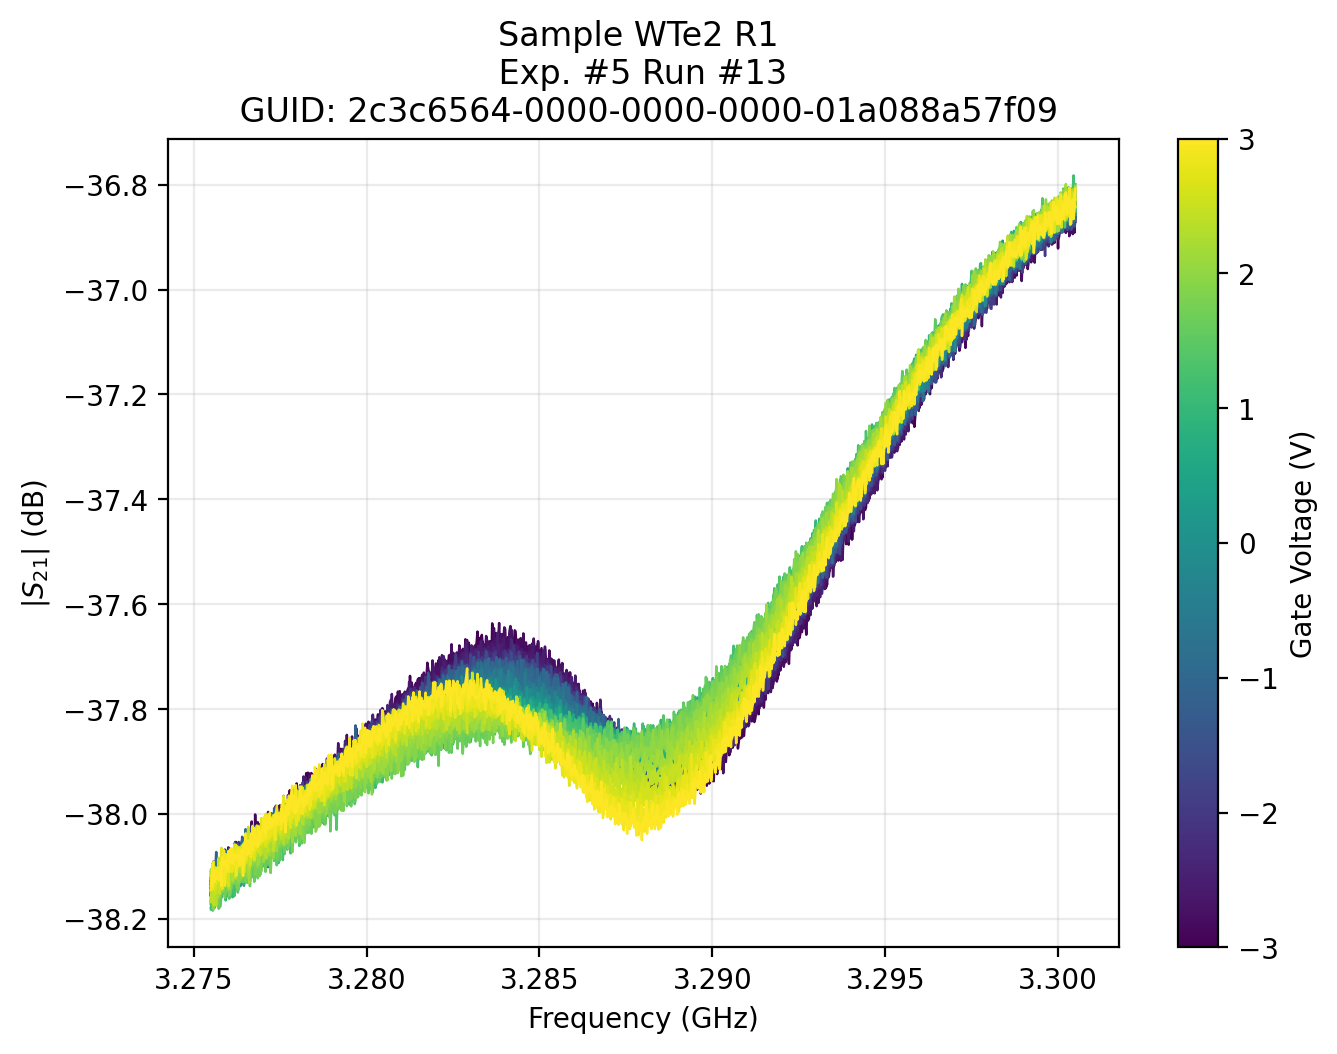

In [201]:
ds = result[0]
print(ds.captured_run_id)
print(ds.exp_id)
print(ds.sample_name)
print(ds.guid)
b = bands[0]
fig,ax = plot_linecuts(ds, b.axis.name.removesuffix("_freq"))
ax.set_title(f"Sample {ds.sample_name} \n Exp. #{ds.exp_id} Run #{ds.captured_run_id} \n GUID: {ds.guid}")

Text(0.5, 1.0, 'GUID: 2c3c6564-0000-0000-0000-01a088a57f09')

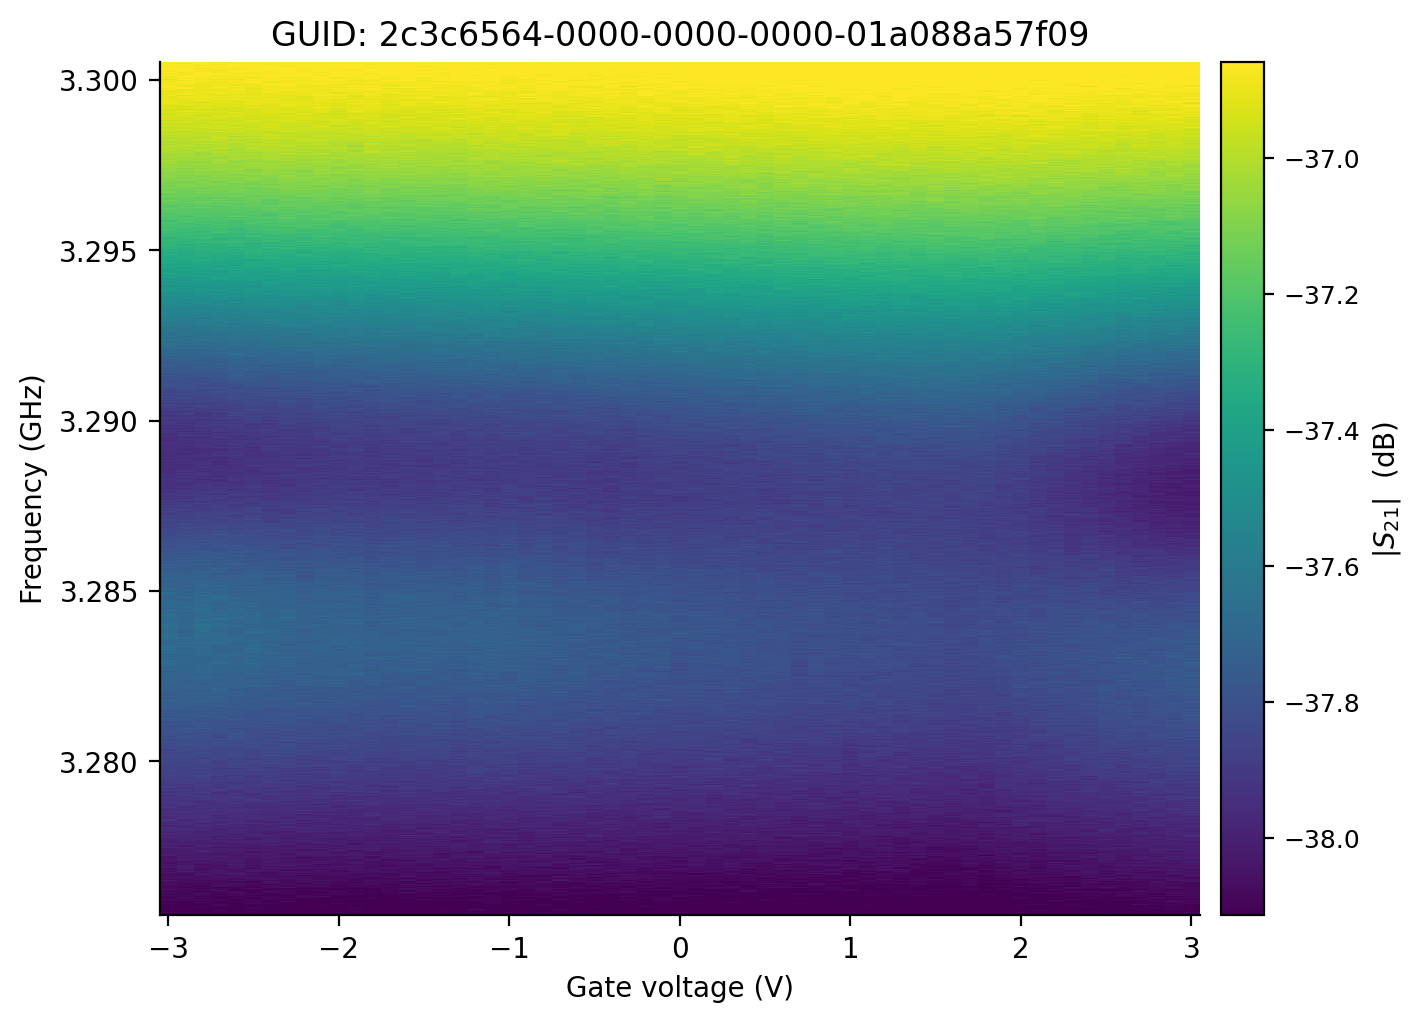

In [232]:
fig,ax = plot_2d(ds,name=b.axis.name.removesuffix("_freq"))
ax.set_title(f"GUID: {ds.guid}")

In [ ]:
from pyCircFit_main import *

In [168]:
def circle_fit(freq,re,im,power,plotResults=True):

    # adapted from Kaushal's code to circle fit S21 data 
    amp_array = re+1j*im
    phase = np.unwrap(np.angle(amp_array))

    phase_corr=False
    if phase_corr:
        phase = np.unwrap(np.angle(amp_array))
        line_delay = (phase[0]-phase[-1])/(freq[0]-freq[-1])
        phase_corr_array = -phase[0]-line_delay*(freq-freq[0])
        amp_corr_array = amp_array * np.exp(1j*phase_corr_array)
        q_corr = np.imag(amp_corr_array)
        i_corr = np.real(amp_corr_array)
        mag_corr = np.sqrt(q_corr**2 + i_corr**2)
        phase_correct = np.unwrap(np.angle(amp_corr_array))
        plt.figure(11)
        plt.scatter(freq,10*np.log10(mag_corr))
        plt.figure(22)
        plt.scatter(freq,phase_correct)
        plt.figure(33)
        plt.scatter(i_corr,q_corr)
        plt.gca().set_aspect('equal')
        cresults = circlefit(freq/1e6, i_corr, q_corr,fittype='hanger', plotlabel='test', plot_detail = False, print_results=False, show_plots=False, fitQscl=1, fano = True)
        fit_data = S21_hanger(cresults['a'], cresults['alpha'], 0, cresults['fr'], 
                            cresults['Qtot'], cresults['Qc'], cresults['phi'], freq/1e6)
    
    i_corr = re
    q_corr = im
    cresults = circlefit(freq/1e6, re, im, fittype='hanger', plotlabel='test', plot_detail = False, print_results=False, show_plots=False, fitQscl=1, fano = True)
    fit_data = S21_hanger(cresults['a'], cresults['alpha'], 0, cresults['fr'], 
                            cresults['Qtot'], cresults['Qc'], cresults['phi'], freq/1e6)
        
        # from Kaushal's code to calculate photon number 
    h = 6.63*1e-34
    q = np.abs(cresults['Qtot'])
    q_err = cresults['Qtot_stderr']
    qc = cresults['Qc']
    qc_err = np.abs(cresults['Qc_stderr'])
    qi = cresults['Qi']
    qi_err = np.abs(cresults['Qi_stderr'])
    f = cresults['fr']*1e6
    f_err = cresults['fr_stderr']
    a = cresults['a']

    # plotting results 
    if (plotResults):
        ## from Kaushal's code to plot circle fit
        plt.figure(figsize=(6,6))
        plt.scatter(i_corr, q_corr, label= 'IQ data', s=12)
        plt.plot(np.real(fit_data), np.imag(fit_data), label='IQ fit', linewidth=6, color='C2')
        plt.legend(fontsize=14, loc='upper right')
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel('I (a.u.)', fontsize=12)
        plt.ylabel('Q (a.u.)', fontsize=12)
        plt.title(r'$\bf{f}$'+f' = {np.round(cresults["fr"]*1e-3,4)} GHz' + r'$\pm $' + 
            f'{np.round(cresults['fr_stderr']*1e3,1)} KHz,' + r'$\bf{Q}_i$' + f' = {np.abs(np.round(cresults["Qi"],1))}' + r'$\pm $' + 
            f'{np.round(cresults['Qi_stderr'],1)},'  + r'$\bf{Q}_c$' + f' = {np.abs(np.round(cresults["Qc"],1))}' + r'$\pm $' + 
            f'{np.round(cresults['Qc_stderr'],1)}', fontsize=12)
        plt.gca().set_aspect('equal')
        plt.show()
    
    #returns results for quantities
    return q,q_err,qc,qc_err,qi,qi_err,f,f_err,p,n,a

In [176]:
sample_real_arr = ds.get_parameter_data('sample_real')['sample_real']['sample_real']
sample_imag_arr = ds.get_parameter_data('sample_imag')['sample_imag']['sample_imag']
sample_freq_arr = ds.get_parameter_data('sample_freq')['sample_freq']['sample_freq']
gate_arr = []
q_arr = []
for idx in range(gate_sweep.num_points):
    sample_real = sample_real_arr[idx,:]
    sample_imag = sample_imag_arr[idx,:]
    sample_freq = sample_freq_arr[idx, :]
    q,q_err,qc,qc_err,qi,qi_err,f,f_err,p,n,a = circle_fit(sample_freq,sample_real,sample_imag,power=-80,plotResults=False)
    gate_arr.append(gate_setpoints[idx])
    q_arr.append(q)

Text(0.5, 1.0, 'Approx. minimum dip.')

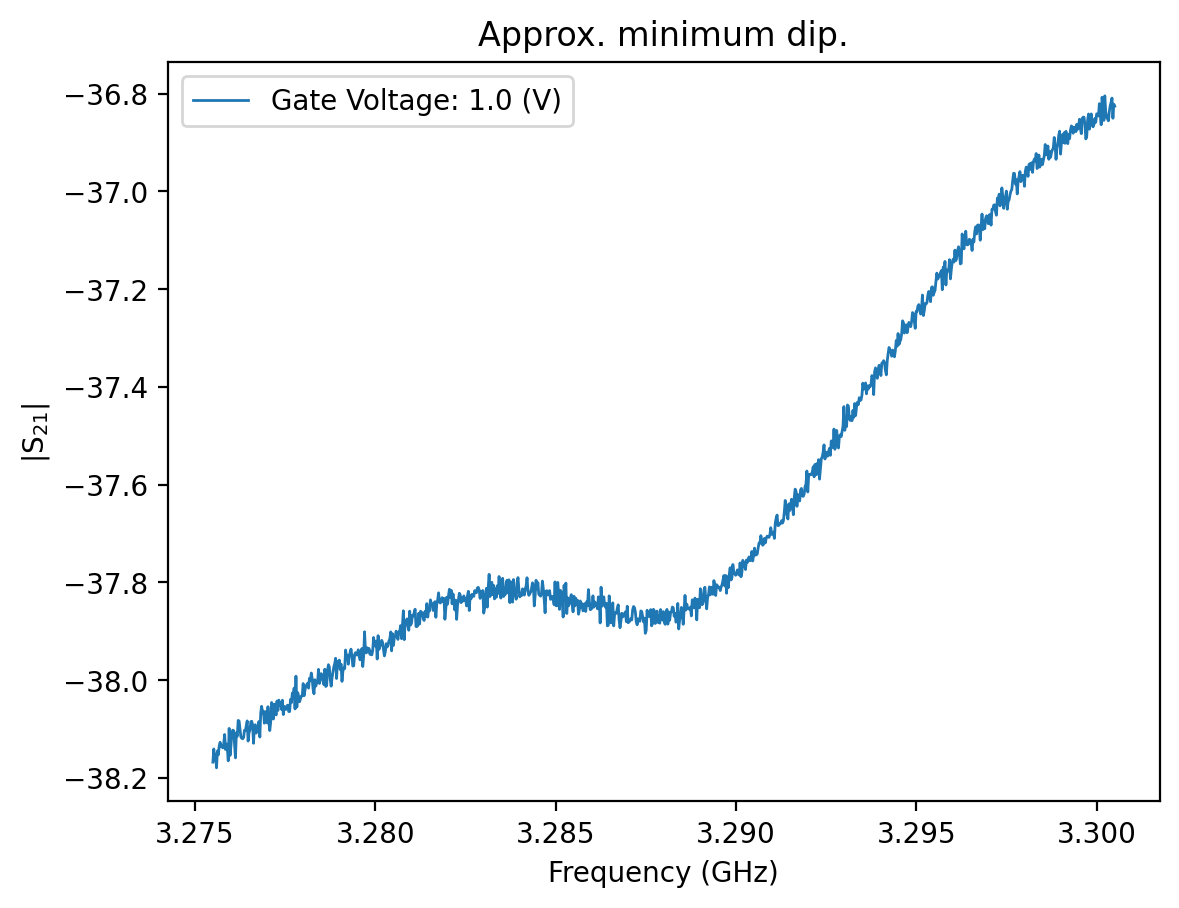

In [226]:
min_idx = np.where(gate_setpoints>=1)[0][0]
fig,ax=plt.subplots()
for idx in [min_idx]:
    sample_real = sample_real_arr[idx,:]
    sample_imag = sample_imag_arr[idx,:]
    sample_mag = 10*np.log10(sample_real**2+sample_imag**2)
    sample_freq = sample_freq_arr[idx, :]
    ax.plot(sample_freq/1e9,sample_mag,linewidth=1,label=f'Gate Voltage: {gate_setpoints[idx]} (V)')
ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("|S$_{21}$|")
ax.set_title("Approx. minimum dip.")

Text(0.5, 1.0, 'Comparing dip depths.')

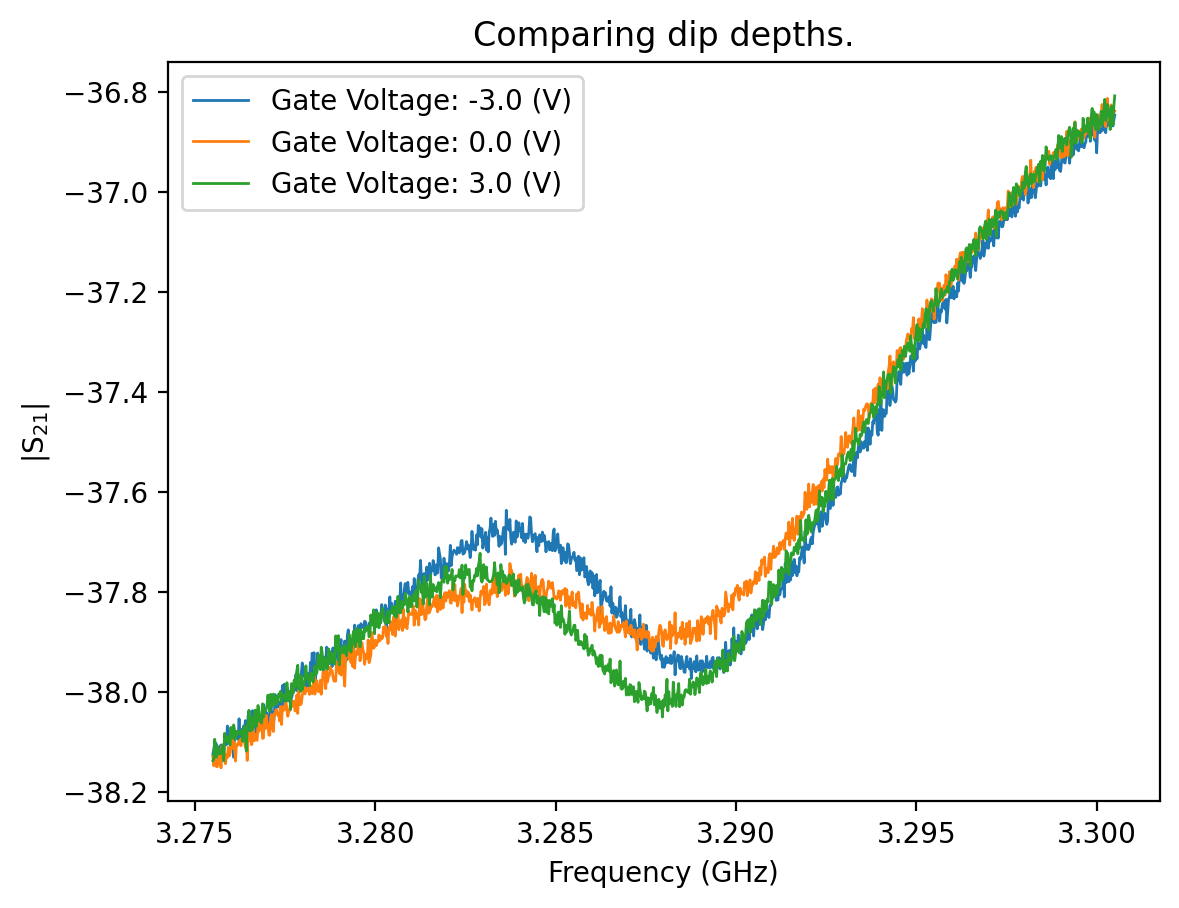

In [206]:
fig,ax=plt.subplots()
for idx in [0,30,-1]:
    sample_real = sample_real_arr[idx,:]
    sample_imag = sample_imag_arr[idx,:]
    sample_mag = 10*np.log10(sample_real**2+sample_imag**2)
    sample_freq = sample_freq_arr[idx, :]
    ax.plot(sample_freq/1e9,sample_mag,linewidth=1,label=f'Gate Voltage: {gate_setpoints[idx]} (V)')
ax.legend()
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("|S$_{21}$|")
ax.set_title("Comparing dip depths.")

2026-09-09 18:36:46,926 :-- INFO --: Mixing Chamber Heater: Setting pid_mode to 1
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-09-09 18:36:47,107 :-- INFO --: Mixing Chamber Heater: Applying settings
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'.

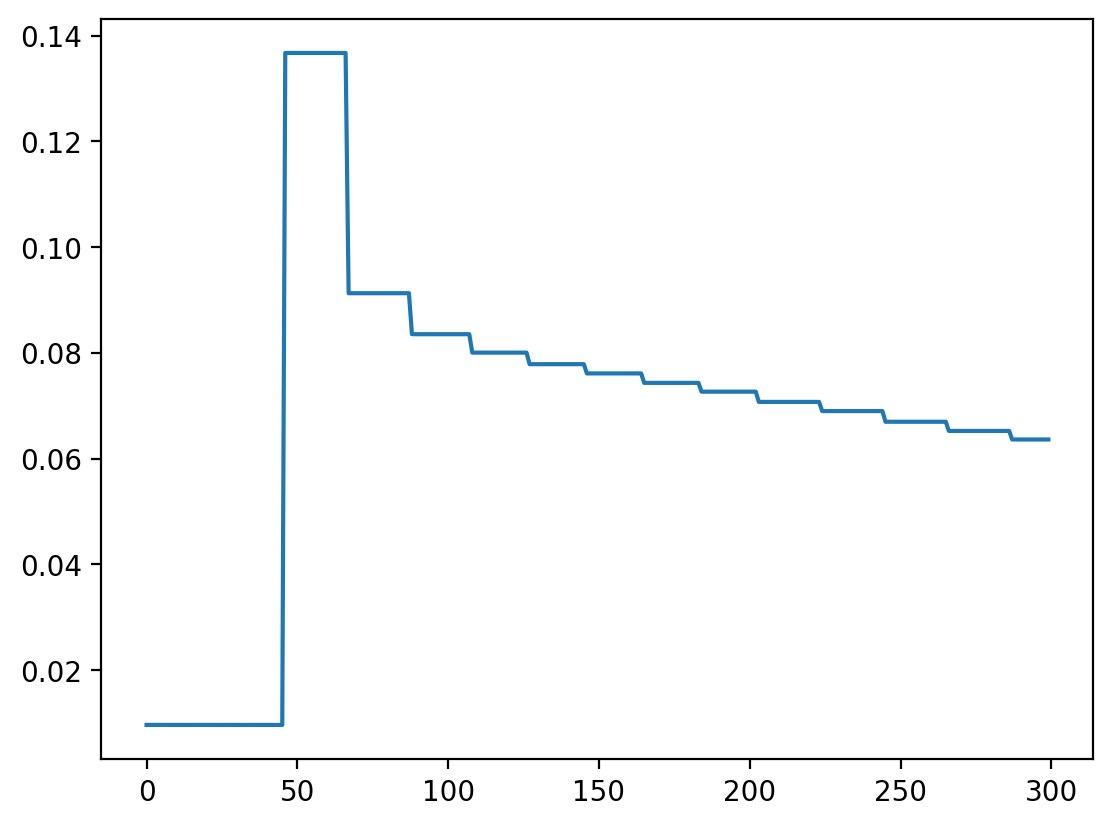

In [207]:
tom.mxc_mode.set(True)
tom.mxc_setpoint.set(50)
times = []
temps = []
for t in range(300):
    try:
        times.append(t)
        temps.append(tom.mxc_temperature.get())
        time.sleep(1)
    except:
        KeyboardInterrupt()
plt.plot(times,temps)

In [208]:
times = []
temps = []
for t in range(300):
    try:
        times.append(t)
        temps.append(tom.mxc_temperature.get())
        time.sleep(1)
    except:
        KeyboardInterrupt()

2026-09-09 18:43:41,023 :-- INFO --: Requesting value: temperature  from channel 6
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-09-09 18:43:42,184 :-- INFO --: Requesting value: temperature  from channel 6
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-09-09 18:43:43,352 :-- INFO --: Requesting value: temperature  from channel 6
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:109

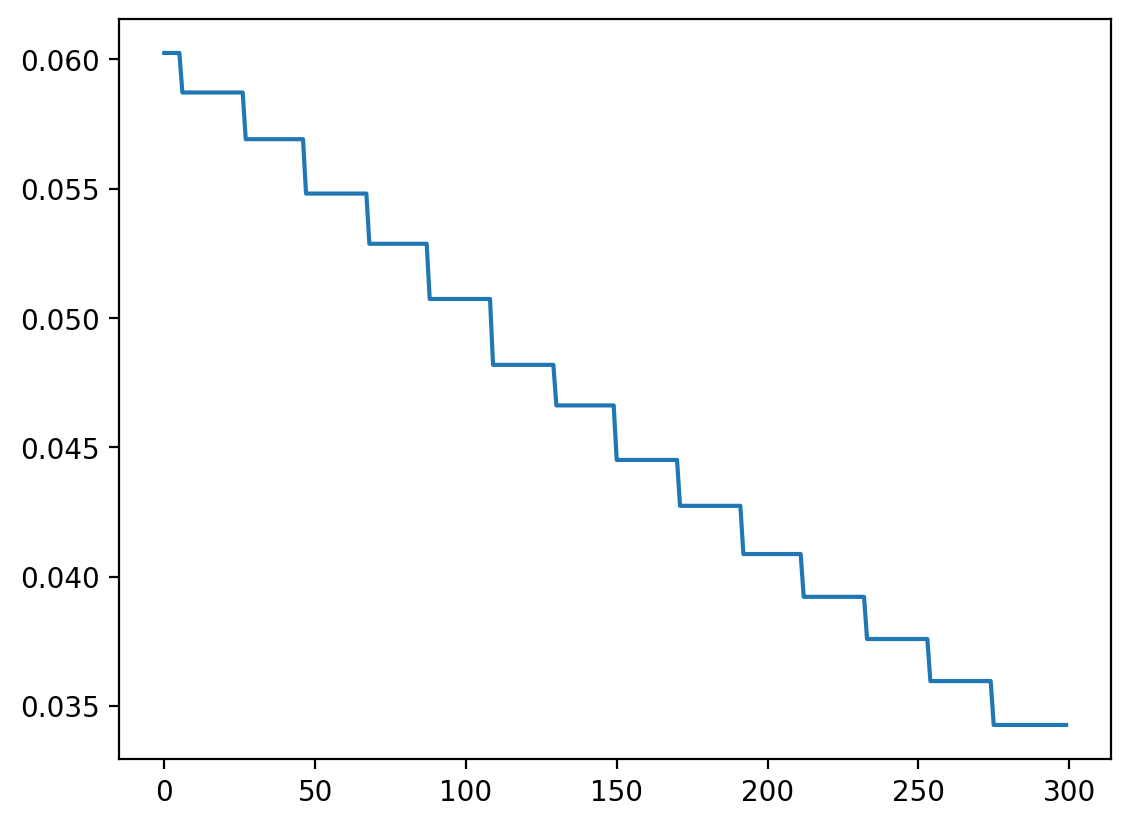

In [221]:
plt.plot(times,temps)

In [240]:
class BlueForsFridgeV2(Instrument):
    def __init__(self, name, **kwargs):
        super().__init__(name, **kwargs)
        self._controller = BlueFTController(ip=IP_ADDRESS, port=PORT_NUMBER, key=API_KEY, 
                                            mixing_chamber_channel_id=MXC_ID,
                                            mixing_chamber_heater_id=MXC_HEATER_ID,
                                            pid_calib_path=PID_CALIB_FILE)
        self.add_parameter("mxc_temperature", unit="K",
            get_cmd=self._controller.get_mxc_temperature)
        self.add_parameter("mxc_setpoint", unit="mK",
            get_cmd=self._controller.get_mxc_heater_setpoint,
            set_cmd= lambda setpoint: self._controller.set_mxc_heater_setpoint(setpoint, use_pid_calib=True)
            )
        self.add_parameter("mxc_mode", 
            get_cmd=self._controller.get_mxc_heater_mode,
            set_cmd=self._controller.set_mxc_heater_mode)

tom = BlueForsFridgeV2(name='Tommy')

2026-09-09 19:38:32,141 :-- INFO --: PID calibration loaded from C:\Users\eseye\Dropbox\TomMeasurement\2D_Materials\WTe2\090726_cooldown_wte2_res1\BlueFTC\examples\pid_calib.csv
2026-09-09 19:38:32,141 :-- INFO --: PID calibration loaded from C:\Users\eseye\Dropbox\TomMeasurement\2D_Materials\WTe2\090726_cooldown_wte2_res1\BlueFTC\examples\pid_calib.csv


2026-09-09 19:39:08,051 :-- INFO --: Mixing Chamber Heater: Setting pid_mode to 1
2026-09-09 19:39:08,051 :-- INFO --: Mixing Chamber Heater: Setting pid_mode to 1
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-09-09 19:39:08,223 :-- INFO --: Mixing Chamber Heater: Applying settings
2026-09-09 19:39:08,223 :-- INFO --: Mixing Chamber Heater: Applying settings
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\eseye\anaco

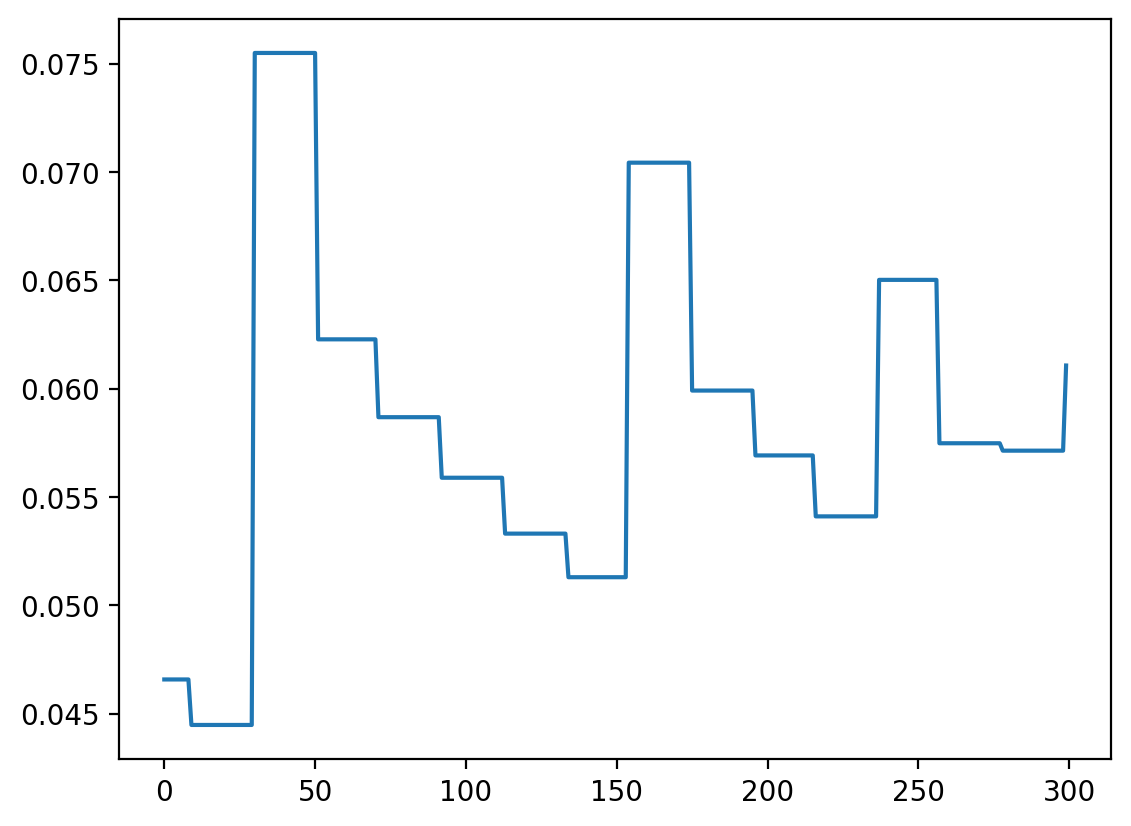

In [241]:
tom.mxc_mode.set(True)
tom.mxc_setpoint.set(60)
times = []
temps = []
for t in range(300):
    try:
        times.append(t)
        temps.append(tom.mxc_temperature.get())
        time.sleep(1)
    except:
        KeyboardInterrupt()
plt.plot(times,temps)

Text(0, 0.5, 'Temperature (K)')

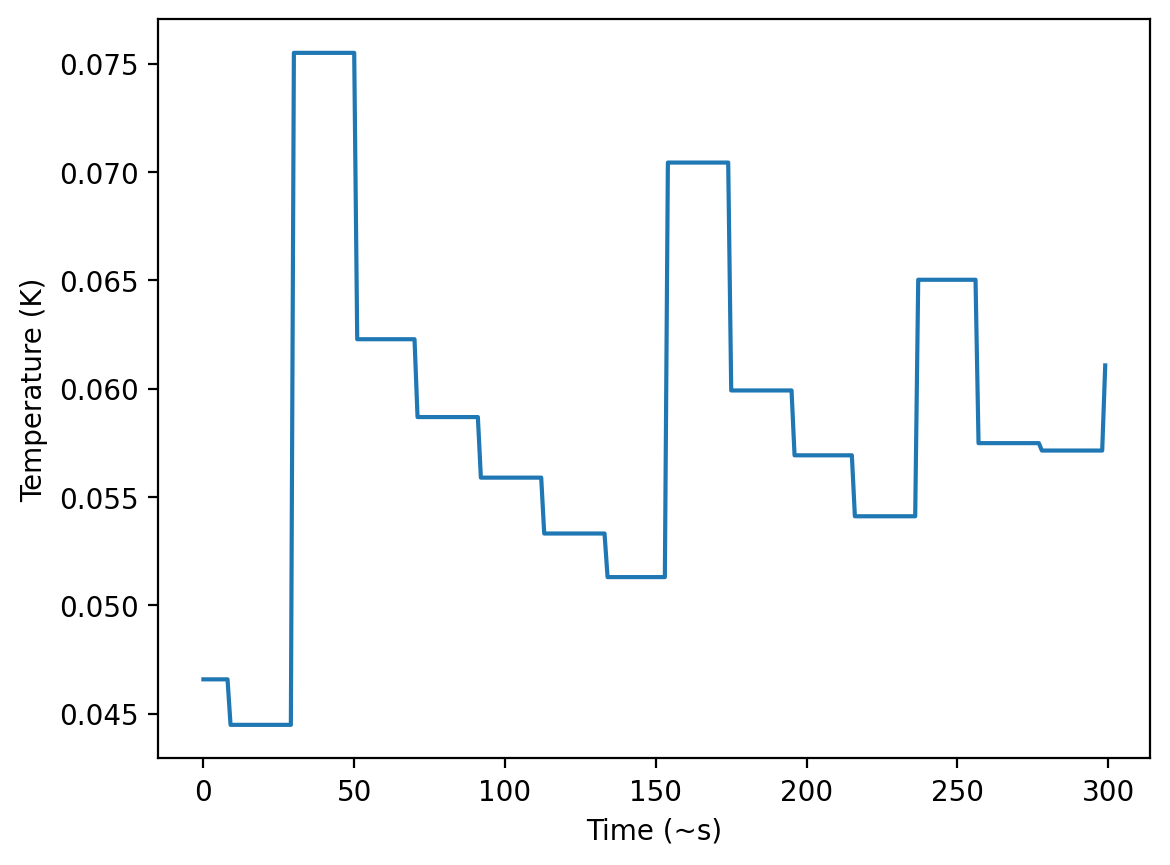

In [242]:
plt.plot(times,temps)
plt.xlabel("Time (~s)")
plt.ylabel("Temperature (K)")

In [253]:
bands = [
    Band("lambda2", 2.965e9,50e6, 500, vna, tr),
    Band("lambda4", 4.186e9,50e6, 500, vna, tr),
    Band("sample", 3.288e9,25e6, 250, vna, tr),
]
GATE_DELAY = 1
gate_setpoints = make_setpoints(-3,3,2.5e-1) # Sweep step size is 250mV.
print('gate_setpoints',gate_setpoints)
gate_sweep = qcodes.dataset.ArraySweep(gate,gate_setpoints,delay=GATE_DELAY)

TEMP_DELAY = 300
temp_setpoints = make_setpoints(50,1000,50)
print('temp_setpoints',temp_setpoints)
temp_sweep = qcodes.dataset.ArraySweep(tom.mxc_setpoint,temp_setpoints,delay=TEMP_DELAY)

gate_setpoints [-3.   -2.75 -2.5  -2.25 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25
  0.    0.25  0.5   0.75  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75
  3.  ]
temp_setpoints [  50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.  600.
  650.  700.  750.  800.  850.  900.  950. 1000.]


In [254]:
result = dond(
    temp_sweep,
    gate_sweep,
    smu.curr,
    tom.mxc_temperature,
    *[p for b in bands for p in (b.acquire, b.real, b.imag)],
    measurement_name="Temperature/gate heatmap -3V to +3V, 50mK to 1K.",
    write_period=1,
    do_plot=False
)

2026-09-09 20:15:52,771 :-- INFO --: Using PID calibration for setpoint 50.0 mK, closest available calibration to 50.0 mK.
2026-09-09 20:15:52,771 :-- INFO --: Using PID calibration for setpoint 50.0 mK, closest available calibration to 50.0 mK.
2026-09-09 20:15:52,772 :-- INFO --: Mixing Chamber Heater: Setting pid_p to 0.04
2026-09-09 20:15:52,772 :-- INFO --: Mixing Chamber Heater: Setting pid_p to 0.04
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-09-09 20:15:52,939 :-- INFO --: Mixing Chamber Heater: Applying settings
2026-09-09 20:15:52,939 :-- INFO --: Mixing Chamber Heater: Applying settings


Starting experimental run with id: 14. Using 'qcodes.dataset.dond'


c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-09-09 20:15:53,786 :-- INFO --: Mixing Chamber Heater: Settings applied and synced
2026-09-09 20:15:53,786 :-- INFO --: Mixing Chamber Heater: Settings applied and synced
2026-09-09 20:15:53,788 :-- INFO --: Mixing Chamber Heater: Setting pid_i to 25.0
2026-09-09 20:15:53,788 :-- INFO --: Mixing Chamber Heater: Setting pid_i to 25.0


In [256]:
tom = BlueForsFridge(name='tom')

In [266]:
"""
Plotting helpers for the temperature / gate / frequency sweep produced by:

    result = dond(temp_sweep, gate_sweep,
                  smu.curr, tom.mxc_temperature,
                  *[p for b in bands for p in (b.acquire, b.real, b.imag)],
                  ...)

The measured mixing-chamber temperature is recorded as a *dependent* parameter
on the (setpoint, gate) grid, not as an axis.  SweepData pulls it out, averages
it over the gate axis at each outer step, and promotes it to a real coordinate
called "T" so both maps are plotted against measured temperature rather than
the PID setpoint.

Usage
-----
    sd = SweepData.from_dond(result)
    print(sd.summary())

    plot_freq_vs_gate(sd, "lambda2", temperature=0.150)   # nearest measured T
    plot_freq_vs_temp(sd, "lambda2", gate=-1.5)           # nearest gate value
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

QUANTITIES = ("mag_db", "mag", "phase", "real", "imag")


# --------------------------------------------------------------------------
# name / dimension resolution
# --------------------------------------------------------------------------

def _find_one(keys, *fragments):
    """Return the single key containing all fragments (case-insensitive)."""
    frags = [f.lower() for f in fragments]
    hits = [k for k in keys if all(f in k.lower() for f in frags)]
    if len(hits) == 1:
        return hits[0]
    raise KeyError(
        f"expected exactly one parameter matching {fragments}, found {hits}. "
        f"Available: {sorted(keys)}"
    )


class SweepData:
    """Lazily-converted view of the dond dataset, keyed by band name."""

    def __init__(
        self,
        dataset,
        temp_param="mxc_temperature",
        temp_dim=None,
        gate_dim=None,
    ):
        self.dataset = dataset
        # One DataArray per dependent parameter.  Using the *dict* form rather
        # than to_xarray_dataset() matters here: the bands have different
        # numbers of frequency points (500/500/250), so a single merged
        # Dataset would pad everything to the longest axis with NaN.
        self.arrays = dataset.to_xarray_dataarray_dict()

        tkey = _find_one(self.arrays, temp_param)
        tda = self.arrays[tkey]
        if len(tda.dims) != 2:
            raise ValueError(
                f"expected {tkey} to live on a 2D (temperature, gate) grid, "
                f"got dims {tda.dims}"
            )

        # Work out which of the two grid dims is the temperature axis.
        if temp_dim is None:
            cand = [
                d for d in tda.dims
                if any(s in d.lower() for s in ("mxc", "setpoint", "temp"))
            ]
            if len(cand) != 1:
                raise ValueError(
                    f"could not identify the temperature dim among {tda.dims}; "
                    "pass temp_dim= and gate_dim= explicitly"
                )
            temp_dim = cand[0]
        if gate_dim is None:
            others = [d for d in tda.dims if d != temp_dim]
            gate_dim = others[0]

        self.temp_dim = temp_dim
        self.gate_dim = gate_dim

        # Measured temperature at each outer step, averaged over the gate
        # sweep (the inner loop runs at nominally fixed T).  The spread tells
        # you whether that average is meaningful.
        self._t_measured = tda.mean(dim=gate_dim, skipna=True)
        self._t_spread = (
            tda.max(dim=gate_dim, skipna=True) - tda.min(dim=gate_dim, skipna=True)
        )

        self.gate_values = np.asarray(tda.coords[gate_dim].values)
        self._band_cache = {}

    @classmethod
    def from_dond(cls, result, **kwargs):
        """Accept either the dond return tuple or a bare DataSet."""
        dataset = result[0] if isinstance(result, tuple) else result
        return cls(dataset, **kwargs)

    # -- temperature bookkeeping -------------------------------------------

    @property
    def temperatures(self):
        """Measured temperature per outer step, in setpoint order."""
        return np.asarray(self._t_measured.values)

    @property
    def temperature_spread(self):
        """max-min of measured T across the gate sweep, per outer step."""
        return np.asarray(self._t_spread.values)

    def summary(self):
        setp = np.asarray(self._t_measured.coords[self.temp_dim].values)
        lines = [f"{len(setp)} temperature steps, {len(self.gate_values)} gate points",
                 f"  {'setpoint':>12}  {'measured':>12}  {'spread':>10}"]
        for s, m, d in zip(setp, self.temperatures, self.temperature_spread):
            lines.append(f"  {s:>12.4g}  {m:>12.4g}  {d:>10.3g}")
        lines.append(f"bands: {', '.join(self.band_names())}")
        return "\n".join(lines)

    # -- band data ---------------------------------------------------------

    def band_names(self):
        return sorted(
            k.lower().rsplit("real", 1)[0].strip("_").rsplit("_", 0)[-1]
            for k in self.arrays if "real" in k.lower()
        )

    def band(self, name):
        """
        Complex S-parameter for one band, as an xarray.DataArray with dims
        ("T", <gate>, <frequency>), sorted by ascending measured temperature.
        """
        if name in self._band_cache:
            return self._band_cache[name]

        rkey = _find_one(self.arrays, name, "real")
        ikey = _find_one(self.arrays, name, "imag")
        da = self.arrays[rkey] + 1j * self.arrays[ikey]
        da.name = name

        missing = set(da.dims) - {self.temp_dim, self.gate_dim}
        if len(missing) != 1:
            raise ValueError(
                f"expected one frequency dim for band {name!r}, got {sorted(missing)}"
            )
        freq_dim = missing.pop()

        da = da.assign_coords({"T": (self.temp_dim, self.temperatures)})
        da = da.swap_dims({self.temp_dim: "T"}).sortby("T")
        da = da.transpose("T", self.gate_dim, freq_dim)
        da.attrs["freq_dim"] = freq_dim

        self._band_cache[name] = da
        return da


# --------------------------------------------------------------------------
# quantity extraction + shared plotting
# --------------------------------------------------------------------------

def _to_quantity(z, quantity, freq_dim=None, unwrap=False):
    if quantity == "mag_db":
        return 20 * np.log10(np.abs(z)), "|S| (dB)"
    if quantity == "mag":
        return np.abs(z), "|S| (lin.)"
    if quantity == "phase":
        ph = np.angle(z)
        if unwrap and freq_dim is not None:
            axis = z.dims.index(freq_dim)
            ph = np.unwrap(ph, axis=axis)
        return np.rad2deg(ph), "phase (deg)"
    if quantity == "real":
        return np.real(z), "Re S"
    if quantity == "imag":
        return np.imag(z), "Im S"
    raise ValueError(f"quantity must be one of {QUANTITIES}, got {quantity!r}")


def _draw(x, y_hz, values, *, xlabel, cbar_label, title, ax, cmap, vmin, vmax):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    mesh = ax.pcolormesh(
        x, np.asarray(y_hz) / 1e9, values,
        shading="nearest", cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("frequency (GHz)")
    ax.set_title(title)
    cbar = ax.figure.colorbar(mesh, ax=ax)
    cbar.set_label(cbar_label)
    return ax.figure, ax, mesh


# --------------------------------------------------------------------------
# the two maps
# --------------------------------------------------------------------------

def plot_freq_vs_gate(
    sd, band, temperature, *, quantity="mag_db", unwrap_phase=False,
    ax=None, cmap="viridis", vmin=None, vmax=None,
):
    """
    Frequency (y) vs gate voltage (x) at the temperature step whose *measured*
    temperature is closest to `temperature`.

    Returns (fig, ax, mesh).  The temperature actually used is in the title
    and on mesh.actual_temperature.
    """
    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel(T=temperature, method="nearest")
    t_actual = float(sel.coords["T"].values)
    sel = sel.transpose(freq_dim, sd.gate_dim)

    values, cbar_label = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    fig, ax, mesh = _draw(
        np.asarray(sel.coords[sd.gate_dim].values),
        sel.coords[freq_dim].values,
        np.asarray(values),
        xlabel="gate voltage (V)",
        cbar_label=cbar_label,
        title=f"{band} — measured T = {t_actual:.4g} (requested {temperature:.4g})",
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
    )
    mesh.actual_temperature = t_actual
    return fig, ax, mesh


def plot_freq_vs_temp(
    sd, band, gate, *, quantity="mag_db", unwrap_phase=False,
    ax=None, cmap="viridis", vmin=None, vmax=None,
):
    """
    Frequency (y) vs measured temperature (x) at the gate point closest to
    `gate`.

    The x axis is the measured MXC temperature, so the columns are not evenly
    spaced even though the setpoints were.  pcolormesh with shading="nearest"
    handles that correctly.

    Returns (fig, ax, mesh).  The gate value actually used is on
    mesh.actual_gate.
    """
    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel({sd.gate_dim: gate}, method="nearest")
    g_actual = float(sel.coords[sd.gate_dim].values)
    sel = sel.transpose(freq_dim, "T")

    values, cbar_label = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    fig, ax, mesh = _draw(
        np.asarray(sel.coords["T"].values),
        sel.coords[freq_dim].values,
        np.asarray(values),
        xlabel=f"measured MXC temperature ({sd.dataset.paramspecs[_find_one(sd.arrays, 'mxc_temperature')].unit or 'a.u.'})",
        cbar_label=cbar_label,
        title=f"{band} — gate = {g_actual:.4g} V (requested {gate:.4g} V)",
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
    )
    mesh.actual_gate = g_actual
    return fig, ax, mesh


def plot_linecuts_vs_temp(
    sd, band, gate, *, quantity="mag_db", unwrap_phase=False,
    temperatures=None, offset=0.0, ax=None, cmap="viridis",
    legend=None, **plot_kw,
):
    """
    Same selection as plot_freq_vs_temp, drawn as overlaid line traces instead
    of a colour map: one curve per temperature step, coloured by measured
    temperature.

    Parameters beyond plot_freq_vs_temp:
        temperatures: subset of measured temperatures to draw (nearest match
            for each).  None draws every step.
        offset: vertical shift applied cumulatively per trace, for a waterfall.
            Units are whatever `quantity` is in (e.g. dB for "mag_db").
        legend: True forces a legend, False forces a colourbar.  Default picks
            a legend for <= 10 traces and a colourbar otherwise.

    Returns (fig, ax, lines).  The gate value actually used is on
    ax.actual_gate.
    """
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel({sd.gate_dim: gate}, method="nearest")
    g_actual = float(sel.coords[sd.gate_dim].values)

    if temperatures is not None:
        wanted = np.atleast_1d(temperatures).astype(float)
        sel = sel.sel(T=list(wanted), method="nearest")
        # nearest-matching two close requests can land on the same step
        _, keep = np.unique(np.asarray(sel.coords["T"].values), return_index=True)
        sel = sel.isel(T=np.sort(keep))

    sel = sel.transpose("T", freq_dim)
    values, ylabel = _to_quantity(sel, quantity, freq_dim, unwrap_phase)
    values = np.asarray(values)

    tvals = np.asarray(sel.coords["T"].values)
    freq_ghz = np.asarray(sel.coords[freq_dim].values) / 1e9

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    cm = plt.get_cmap(cmap)
    lo, hi = float(np.min(tvals)), float(np.max(tvals))
    norm = Normalize(vmin=lo, vmax=hi if hi > lo else lo + 1.0)

    lines = []
    for i, t in enumerate(tvals):
        (line,) = ax.plot(
            freq_ghz, values[i] + i * offset,
            color=cm(norm(t)), label=f"T = {t:.4g}", **plot_kw,
        )
        lines.append(line)

    ax.set_xlabel("frequency (GHz)")
    ax.set_ylabel(ylabel + (" + offset" if offset else ""))
    ax.set_title(f"{band} — gate = {g_actual:.4g} V (requested {gate:.4g} V)")

    if legend is None:
        legend = len(tvals) <= 10
    if legend:
        ax.legend(fontsize="small", ncol=1 + len(tvals) // 12)
    else:
        sm = ScalarMappable(norm=norm, cmap=cm)
        sm.set_array([])
        ax.figure.colorbar(sm, ax=ax).set_label("measured MXC temperature")

    ax.actual_gate = g_actual
    return ax.figure, ax, lines

In [267]:
sd = SweepData.from_dond(result)
print(sd.summary())

20 temperature steps, 25 gate points
      setpoint      measured      spread
            50       0.05063      0.0164
           100           0.1      0.0212
           150        0.1495      0.0368
           200        0.2006      0.0458
           250        0.2519      0.0405
           300        0.2987      0.0426
           350        0.3504        0.04
           400        0.4012      0.0334
           450        0.4509      0.0399
           500        0.5013      0.0383
           550        0.5504      0.0349
           600        0.5773     0.00896
           650        0.5723      0.0045
           700        0.5684      0.0097
           750         0.566     0.00857
           800        0.5637     0.00809
           850        0.5631     0.00693
           900        0.5605     0.00689
           950        0.5602      0.0102
          1000        0.5581     0.00887
bands: lambda2, lambda4, sample


(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — gate = 3 V (requested 3 V)'}, xlabel='frequency (GHz)', ylabel='|S| (dB)'>,
  <matplotlib.lines.Line2D at 0x2b3139b7410>])

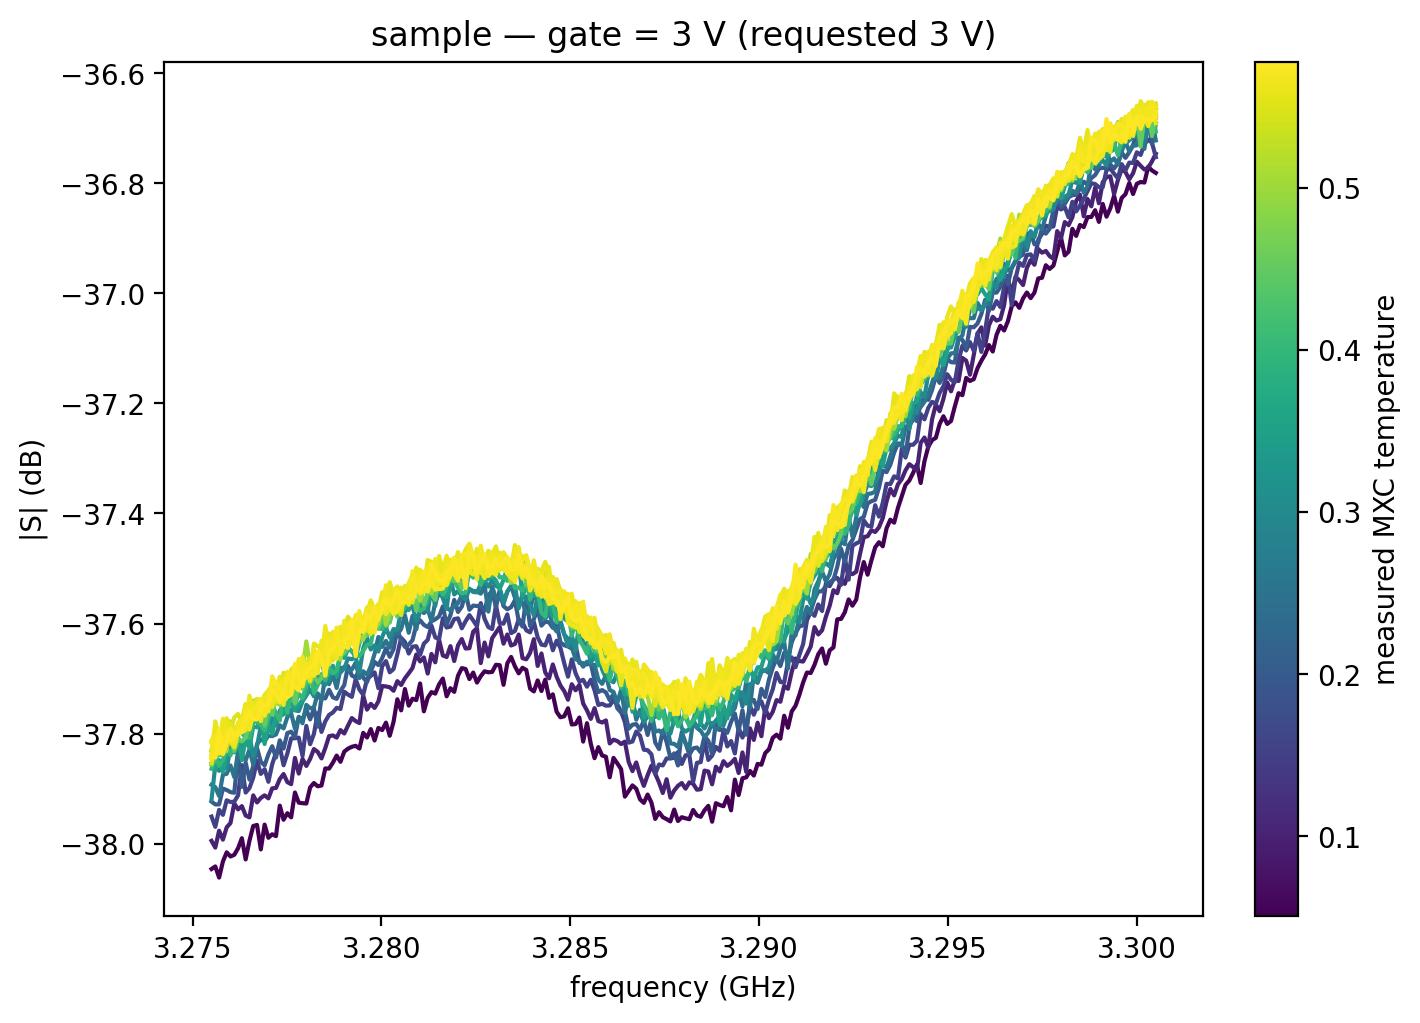

In [269]:
# waterfall, 2 dB between traces, so overlapping resonances stay readable
plot_linecuts_vs_temp(sd, "sample", gate=3, offset=0)

In [ ]:
# just the ends and the middle
plot_linecuts_vs_temp(sd, "sample", gate=-3, temperatures=[0.05, 0.3, 0.6, 1.0])

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — measured T = 0.5013 (requested 0.5)'}, xlabel='gate voltage (V)', ylabel='frequency (GHz)'>,
 <matplotlib.collections.QuadMesh at 0x2b2ff323f50>)

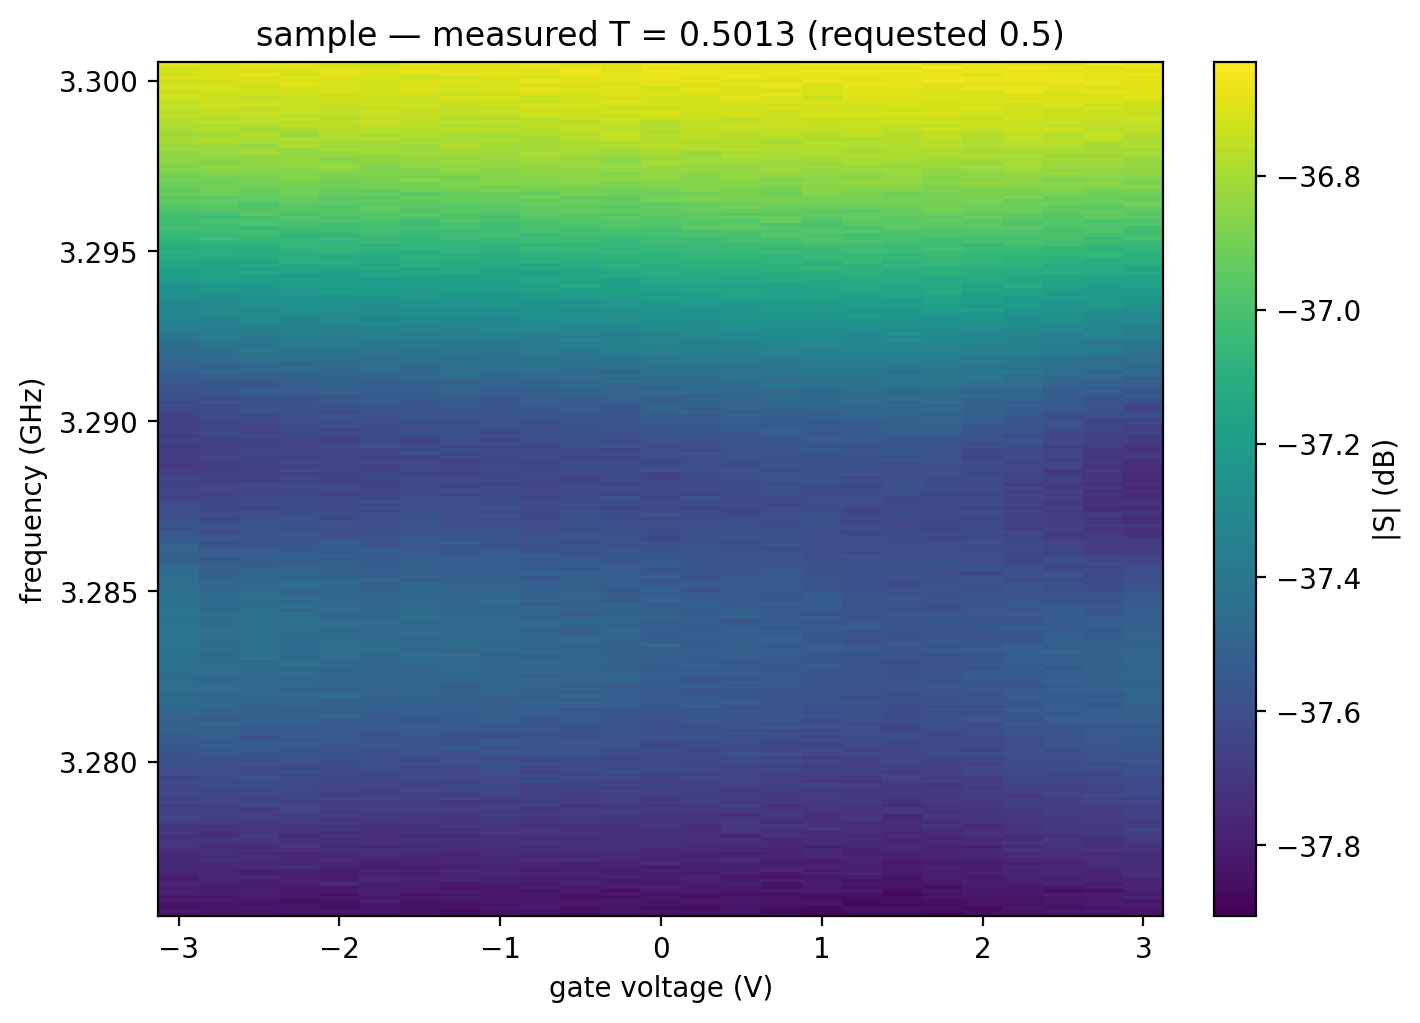

In [260]:
plot_freq_vs_gate(sd, "sample", temperature=0.5)   # nearest measured T

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — gate = 3 V (requested 3 V)'}, xlabel='measured MXC temperature (K)', ylabel='frequency (GHz)'>,
 <matplotlib.collections.QuadMesh at 0x2b31726a570>)

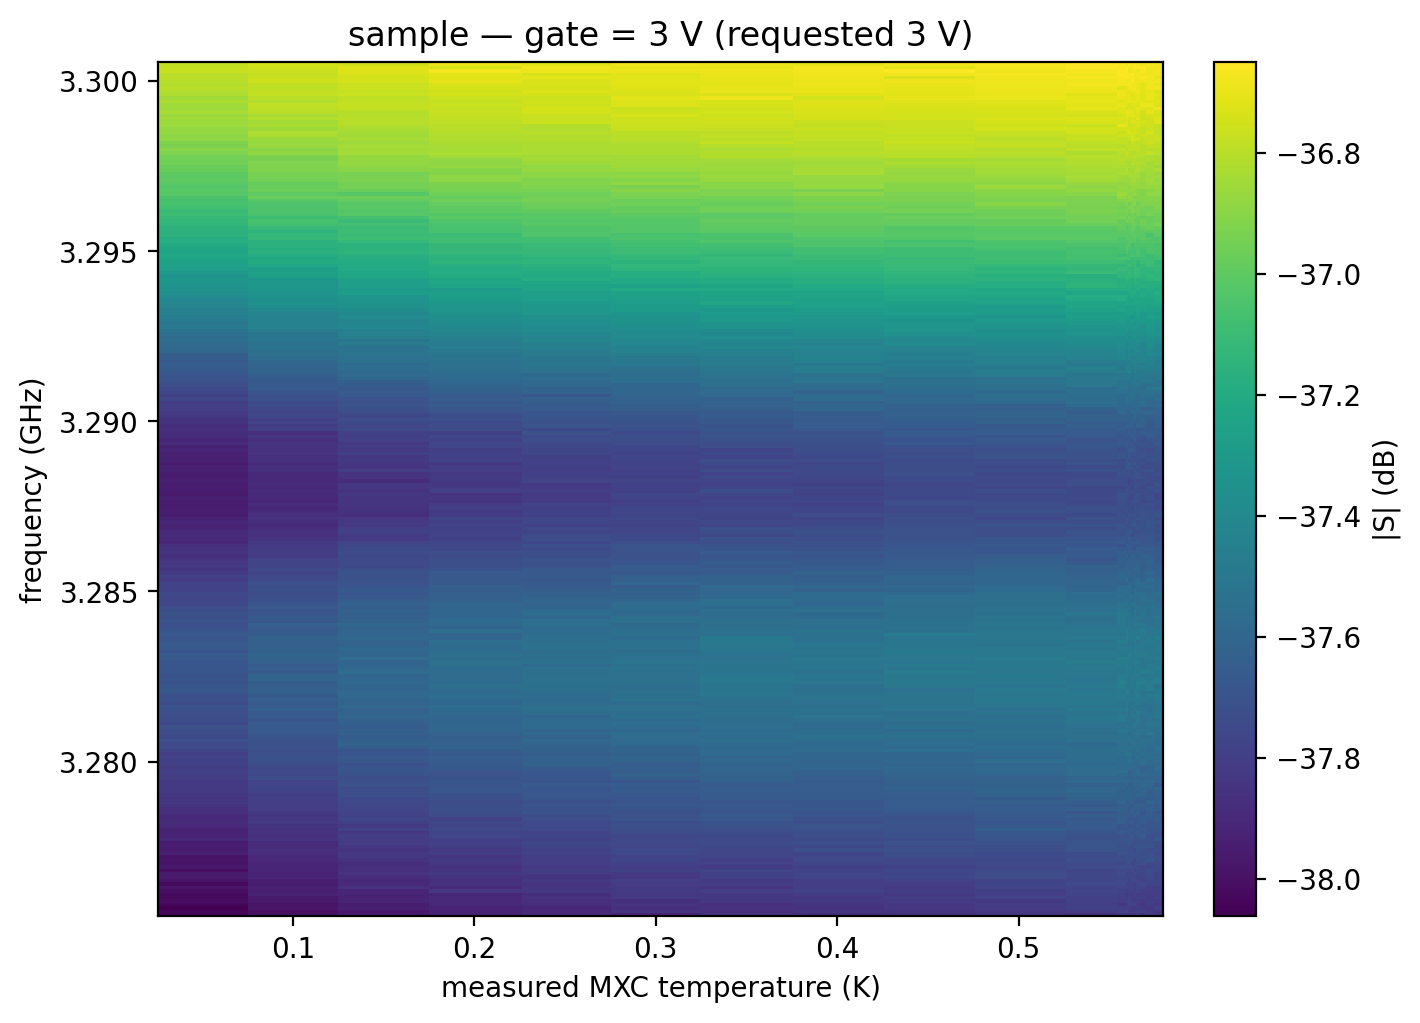

In [270]:
plot_freq_vs_temp(sd, "sample", gate=3)

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'lambda4 — gate = 3 V (requested 3 V)'}, xlabel='measured MXC temperature (K)', ylabel='frequency (GHz)'>,
 <matplotlib.collections.QuadMesh at 0x2b2ff17ef60>)

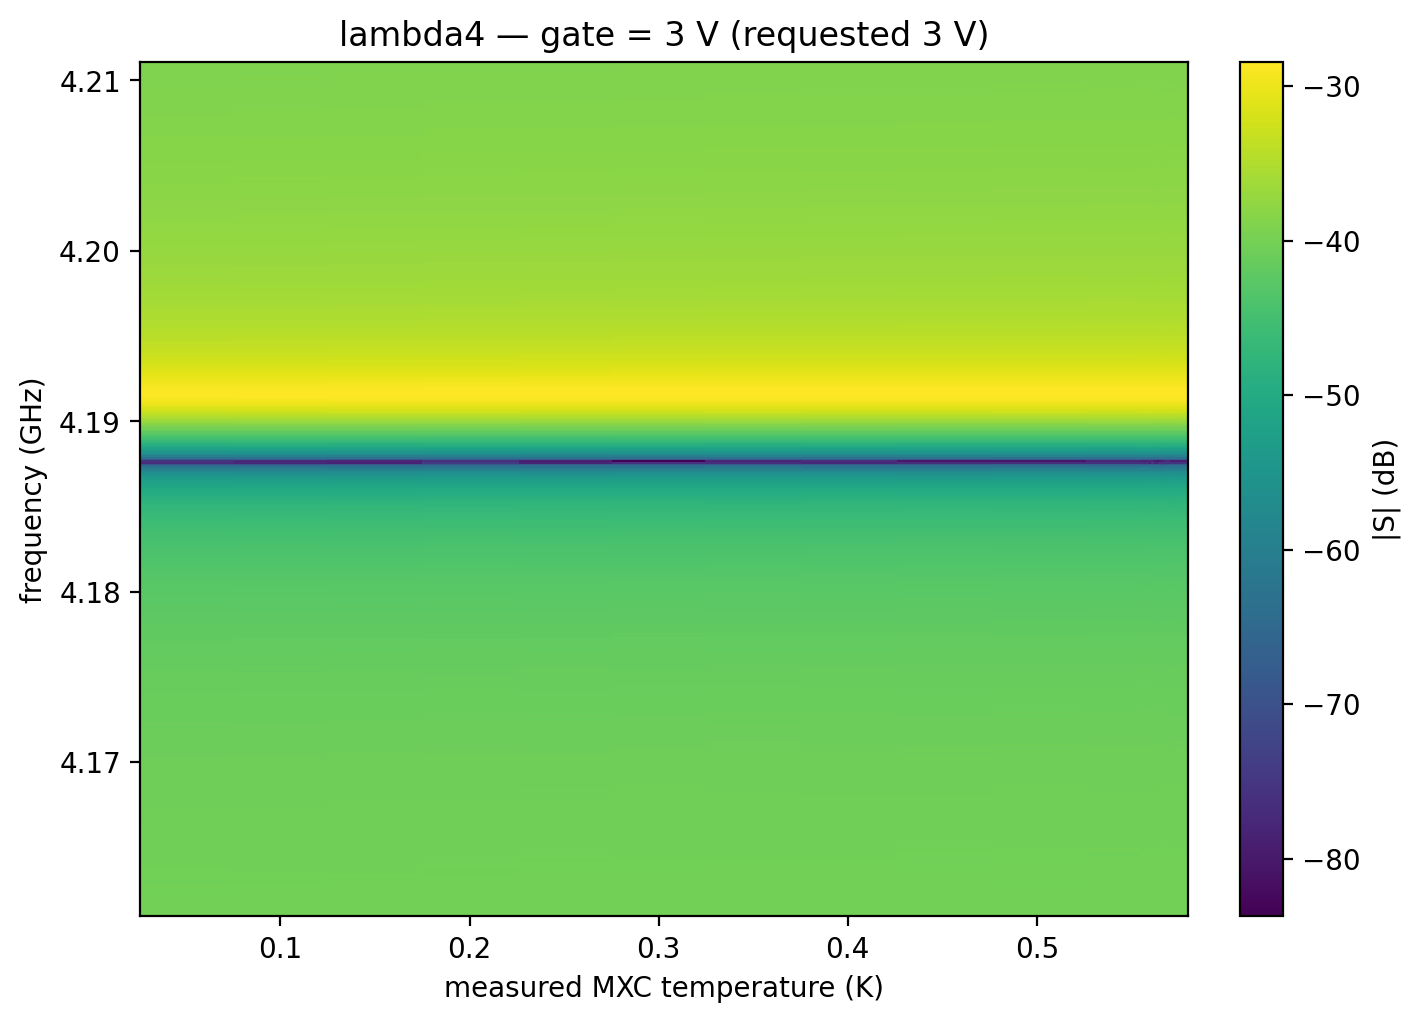

In [272]:
plot_freq_vs_temp(sd, "lambda4", gate=3)

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — gate = -3 V (requested -3 V)'}, xlabel='measured MXC temperature (K)', ylabel='frequency (GHz)'>,
 <matplotlib.collections.QuadMesh at 0x2b2ff65dbe0>)

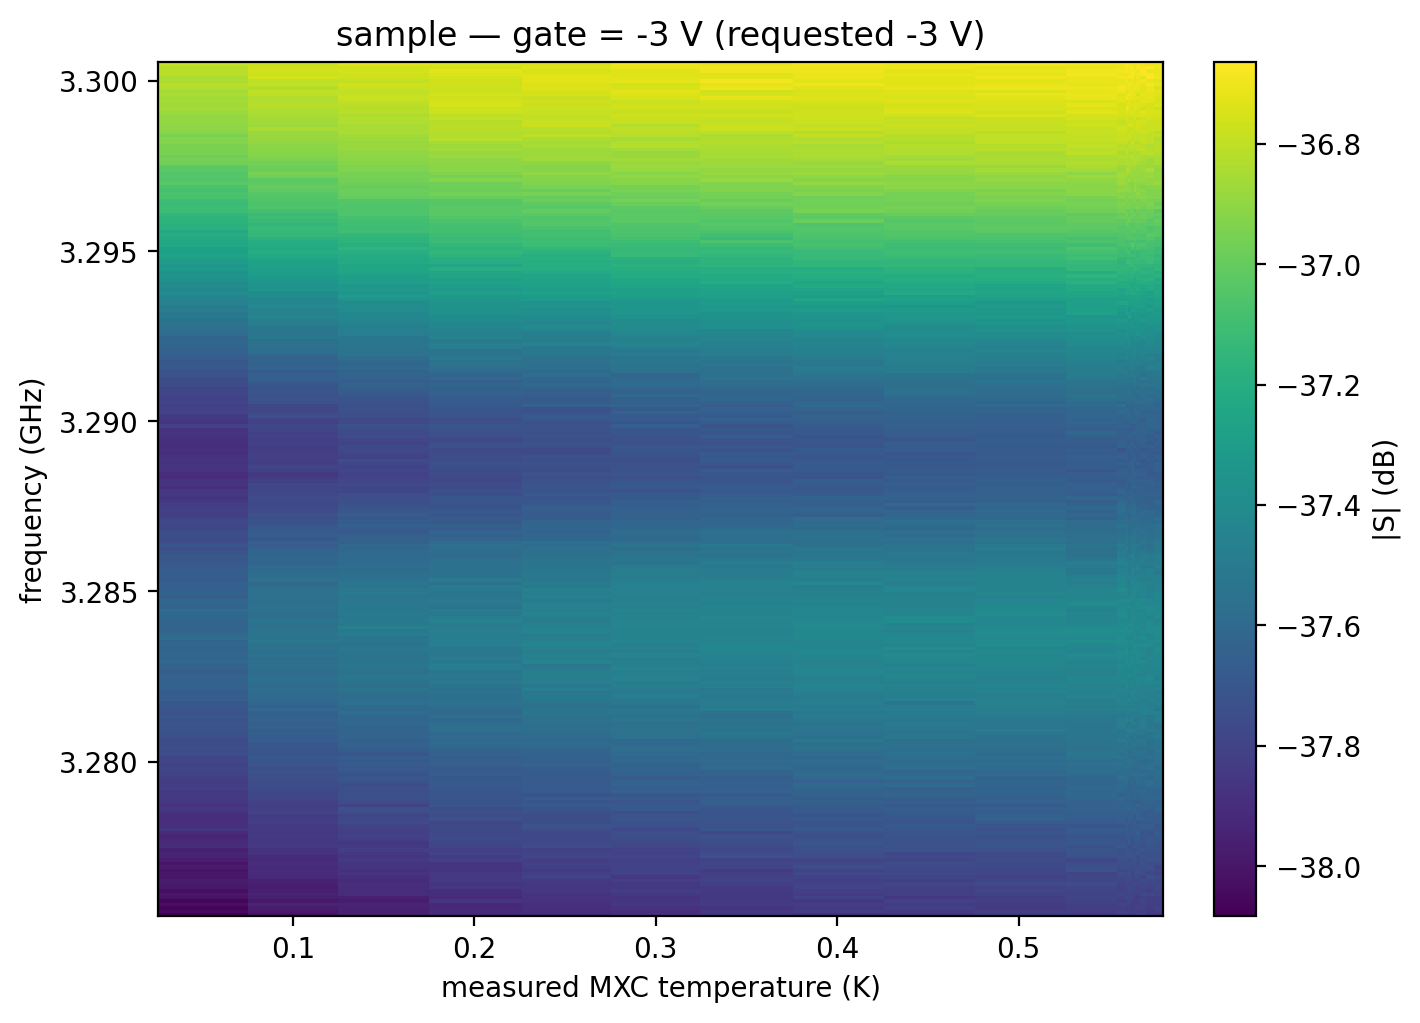

In [273]:
plot_freq_vs_temp(sd, "sample", gate=-3)

In [274]:
# Repeating temperature sweep going up to 1K.
tom.mxc_mode()

c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


True

In [276]:
tom = BlueForsFridgeV2(name='TomV2')

2026-09-10 11:13:01,301 :-- INFO --: PID calibration loaded from C:\Users\eseye\Dropbox\TomMeasurement\2D_Materials\WTe2\090726_cooldown_wte2_res1\BlueFTC\examples\pid_calib.csv
2026-09-10 11:13:01,301 :-- INFO --: PID calibration loaded from C:\Users\eseye\Dropbox\TomMeasurement\2D_Materials\WTe2\090726_cooldown_wte2_res1\BlueFTC\examples\pid_calib.csv
2026-09-10 11:13:01,301 :-- INFO --: PID calibration loaded from C:\Users\eseye\Dropbox\TomMeasurement\2D_Materials\WTe2\090726_cooldown_wte2_res1\BlueFTC\examples\pid_calib.csv
2026-09-10 11:13:01,301 :-- INFO --: PID calibration loaded from C:\Users\eseye\Dropbox\TomMeasurement\2D_Materials\WTe2\090726_cooldown_wte2_res1\BlueFTC\examples\pid_calib.csv
2026-09-10 11:13:01,301 :-- INFO --: PID calibration loaded from C:\Users\eseye\Dropbox\TomMeasurement\2D_Materials\WTe2\090726_cooldown_wte2_res1\BlueFTC\examples\pid_calib.csv


In [278]:
tom.mxc_mode()

c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


True

In [280]:
tom.mxc_temperature()
tom.mxc_setpoint()

2026-09-10 11:14:22,764 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 11:14:22,764 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 11:14:22,764 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 11:14:22,764 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 11:14:22,764 :-- INFO --: Requesting value: temperature  from channel 6
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.

0.0

In [286]:
tom.mxc_setpoint.set(100)

2026-09-10 15:30:30,257 :-- INFO --: Using PID calibration for setpoint 100.0 mK, closest available calibration to 100 mK.
2026-09-10 15:30:30,257 :-- INFO --: Using PID calibration for setpoint 100.0 mK, closest available calibration to 100 mK.
2026-09-10 15:30:30,257 :-- INFO --: Using PID calibration for setpoint 100.0 mK, closest available calibration to 100 mK.
2026-09-10 15:30:30,257 :-- INFO --: Using PID calibration for setpoint 100.0 mK, closest available calibration to 100 mK.
2026-09-10 15:30:30,257 :-- INFO --: Using PID calibration for setpoint 100.0 mK, closest available calibration to 100 mK.
2026-09-10 15:30:30,259 :-- INFO --: Mixing Chamber Heater: Setting pid_p to 0.06
2026-09-10 15:30:30,259 :-- INFO --: Mixing Chamber Heater: Setting pid_p to 0.06
2026-09-10 15:30:30,259 :-- INFO --: Mixing Chamber Heater: Setting pid_p to 0.06
2026-09-10 15:30:30,259 :-- INFO --: Mixing Chamber Heater: Setting pid_p to 0.06
2026-09-10 15:30:30,259 :-- INFO --: Mixing Chamber Heate

In [ ]:
import time
import matplotlib.pyplot as plt

plt.ion()
fig, ax = plt.subplots()
line, = ax.plot([], [], '.-')
ax.set_xlabel('elapsed time (s)')
ax.set_ylabel('MXC temperature (K)')

times, temps = [], []
t0 = time.monotonic()

try:
    for _ in range(300):
        times.append(time.monotonic() - t0)
        temps.append(tom.mxc_temperature.get())

        line.set_data(times, temps)
        ax.relim()
        ax.autoscale_view()
        fig.canvas.draw_idle()
        fig.canvas.flush_events()

        time.sleep(1)
except KeyboardInterrupt:
    print(f'stopped early, {len(times)} points collected')

plt.ioff()
plt.show()

2026-09-10 15:30:38,792 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 15:30:38,792 :-- INFO --: Requesting value: temperature  from channel 6


2026-09-10 15:30:38,792 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 15:30:38,792 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 15:30:38,792 :-- INFO --: Requesting value: temperature  from channel 6
c:\Users\eseye\anaconda3\envs\BoettcherBase\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.32.83.100'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-09-10 15:30:39,978 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 15:30:39,978 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 15:30:39,978 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 15:30:39,978 :-- INFO --: Requesting value: temperature  from channel 6
2026-09-10 15:30:39,978 :-- INFO --: Requesting value: temperature  from channel 6
c:\Use

TODO: 

Measurements:
- Full gated heatmap overnight: -3V to +3V and 50mK to 1K.
- Sweep up to 5V to look for SC phase!

Analysis:
- Background substrate + circle fit resonance dips and extract impedance.
    - Compare to circuit model.

Code:
- Create a class for gated RF measurements, gated RF measurements versus temperature, etc., that wraps the dond() and sweep definitions into one.
- Create 2D-sensing environment and install BlueFors and measurement/analysis code as packages.
- YAML files for instrument configuration.
- Sweeping + plotting + analysis functions live in their own imported modules.
- Add metadata to each dataset.
- Create a python environment where this code can be installed as a package.